## World Development Measure

### Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from sklearn.metrics import (silhouette_score,davies_bouldin_score,calinski_harabasz_score)
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

In [28]:
df = pd.read_excel("P706_ World_development_mesurement.xlsx")
df

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,NaN,0.034,0.0,0.100,71.0,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,NaN,0.128,0.0,1.032,47.0,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,NaN,0.090,0.0,NaN,57.0,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,NaN,0.054,0.0,0.155,52.0,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,NaN,0.096,0.0,NaN,52.0,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,NaN,NaN,NaN,Turks and Caicos Islands,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,32427,0.911,NaN,NaN
2700,0.013,46.4%,NaN,United States,5.0,4.0,2132446.0,"$16,244,600,000,000",0.179,"$8,895",175.0,0.006,0.8,0.033,81.0,76.0,1.0,1,0.196,0.667,0.136,313873685,0.811,"$200,092,000,000","$126,573,000,000"
2701,0.015,41.9%,NaN,Uruguay,7.0,85.0,NaN,"$50,004,354,667",0.089,"$1,308",310.0,0.010,0.5,0.112,80.0,74.0,1.5,1,0.220,0.639,0.140,3395253,0.948,"$2,222,000,000","$1,028,000,000"
2702,0.020,61.9%,NaN,"Venezuela, RB",144.0,180.0,NaN,"$381,286,223,859",0.046,$593,792.0,0.013,0.5,0.164,78.0,72.0,1.0,1,0.288,0.652,0.060,29954782,0.889,"$904,000,000","$3,202,000,000"


### EDA

#### Data Cleaning

In [29]:
df.head(5)

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,NaN,0.034,0.0,0.100,71.0,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,NaN,0.128,0.0,1.032,47.0,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,NaN,0.090,0.0,NaN,57.0,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,NaN,0.054,0.0,0.155,52.0,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,NaN,0.096,0.0,NaN,52.0,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [31]:
df.dtypes

Birth Rate                float64
Business Tax Rate          object
CO2 Emissions             float64
Country                    object
Days to Start Business    float64
Ease of Business          float64
Energy Usage              float64
GDP                        object
Health Exp % GDP          float64
Health Exp/Capita          object
Hours to do Tax           float64
Infant Mortality Rate     float64
Internet Usage            float64
Lending Interest          float64
Life Expectancy Female    float64
Life Expectancy Male      float64
Mobile Phone Usage        float64
Number of Records           int64
Population 0-14           float64
Population 15-64          float64
Population 65+            float64
Population Total            int64
Population Urban          float64
Tourism Inbound            object
Tourism Outbound           object
dtype: object

In [32]:
#Selecting all float columns
def check_decimal_values(df):
    #Checking each float column for decimal values
    float_cols = df.select_dtypes(include='float').columns
    for col in float_cols:
        #Checking whether the column contains any decimal values
        has_decimal = df[col].dropna().apply(lambda x: x % 1 != 0).any()
        print(f"{col}: {'Has decimal values' if has_decimal else 'No decimal values'}")

In [33]:
check_decimal_values(df)

Birth Rate: Has decimal values
CO2 Emissions: No decimal values
Days to Start Business: No decimal values
Ease of Business: No decimal values
Energy Usage: No decimal values
Health Exp % GDP: Has decimal values
Hours to do Tax: No decimal values
Infant Mortality Rate: Has decimal values
Internet Usage: Has decimal values
Lending Interest: Has decimal values
Life Expectancy Female: No decimal values
Life Expectancy Male: No decimal values
Mobile Phone Usage: Has decimal values
Population 0-14: Has decimal values
Population 15-64: Has decimal values
Population 65+: Has decimal values
Population Urban: Has decimal values


In [34]:
#Dropping Ease of Business due to very high missing values (~93%)
df.drop('Ease of Business', axis=1, inplace=True)

In [35]:
#Converting Business Tax Rate from percentage string to float
df['Business Tax Rate'] = (
    df['Business Tax Rate']
    .str.replace('%', '', regex=False)
    .astype(float)
)

In [36]:
#Converting financial columns from string to float
money_cols = [
    'GDP',
    'Health Exp/Capita',
    'Tourism Inbound',
    'Tourism Outbound'
]
for col in money_cols:
    df[col] = (
        df[col]
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

In [37]:
print("Unique countries:", df['Country'].nunique())
print("Records per country:")
print(df['Country'].value_counts())

Unique countries: 208
Records per country:
Country
Algeria                  13
Angola                   13
Turkey                   13
Ukraine                  13
United Kingdom           13
                         ..
Malaysia                 13
Maldives                 13
Mongolia                 13
Myanmar                  13
Virgin Islands (U.S.)    13
Name: count, Length: 208, dtype: int64


The dataset contains 208 unique countries, with each country appearing exactly 13 times.

In [38]:
df.dtypes

Birth Rate                float64
Business Tax Rate         float64
CO2 Emissions             float64
Country                    object
Days to Start Business    float64
Energy Usage              float64
GDP                       float64
Health Exp % GDP          float64
Health Exp/Capita         float64
Hours to do Tax           float64
Infant Mortality Rate     float64
Internet Usage            float64
Lending Interest          float64
Life Expectancy Female    float64
Life Expectancy Male      float64
Mobile Phone Usage        float64
Number of Records           int64
Population 0-14           float64
Population 15-64          float64
Population 65+            float64
Population Total            int64
Population Urban          float64
Tourism Inbound           float64
Tourism Outbound          float64
dtype: object

In [39]:
df.isnull().sum()

Birth Rate                 119
Business Tax Rate         1281
CO2 Emissions              579
Country                      0
Days to Start Business     986
Energy Usage               919
GDP                        210
Health Exp % GDP           309
Health Exp/Capita          309
Hours to do Tax           1288
Infant Mortality Rate      260
Internet Usage             173
Lending Interest           824
Life Expectancy Female     136
Life Expectancy Male       136
Mobile Phone Usage         167
Number of Records            0
Population 0-14            220
Population 15-64           220
Population 65+             220
Population Total             0
Population Urban            26
Tourism Inbound            368
Tourism Outbound           471
dtype: int64

In [40]:
def null_percentage(df):
    return (df.isnull().sum()/len(df)*100).round(2)

In [41]:
null_percentage(df)

Birth Rate                 4.40
Business Tax Rate         47.37
CO2 Emissions             21.41
Country                    0.00
Days to Start Business    36.46
Energy Usage              33.99
GDP                        7.77
Health Exp % GDP          11.43
Health Exp/Capita         11.43
Hours to do Tax           47.63
Infant Mortality Rate      9.62
Internet Usage             6.40
Lending Interest          30.47
Life Expectancy Female     5.03
Life Expectancy Male       5.03
Mobile Phone Usage         6.18
Number of Records          0.00
Population 0-14            8.14
Population 15-64           8.14
Population 65+             8.14
Population Total           0.00
Population Urban           0.96
Tourism Inbound           13.61
Tourism Outbound          17.42
dtype: float64

In [42]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

In [43]:
#Imputing missing values at countrl level
df[numeric_cols] = df.groupby('Country')[numeric_cols].transform(
    lambda x: x.fillna(x.median())
)

In [44]:
df.isnull().sum()

Birth Rate                 26
Business Tax Rate         299
CO2 Emissions             169
Country                     0
Days to Start Business    299
Energy Usage              533
GDP                       143
Health Exp % GDP          299
Health Exp/Capita         299
Hours to do Tax           299
Infant Mortality Rate     260
Internet Usage            117
Lending Interest          585
Life Expectancy Female     65
Life Expectancy Male       65
Mobile Phone Usage         65
Number of Records           0
Population 0-14           208
Population 15-64          208
Population 65+            208
Population Total            0
Population Urban           26
Tourism Inbound           208
Tourism Outbound          286
dtype: int64

In [45]:
#Calculating the percentage of missing values in each column and sorting them from highest to lowest
(df.isnull().mean() * 100).sort_values(ascending=False).round(2)

Lending Interest          21.63
Energy Usage              19.71
Health Exp % GDP          11.06
Business Tax Rate         11.06
Hours to do Tax           11.06
Days to Start Business    11.06
Health Exp/Capita         11.06
Tourism Outbound          10.58
Infant Mortality Rate      9.62
Population 0-14            7.69
Population 15-64           7.69
Population 65+             7.69
Tourism Inbound            7.69
CO2 Emissions              6.25
GDP                        5.29
Internet Usage             4.33
Life Expectancy Female     2.40
Life Expectancy Male       2.40
Mobile Phone Usage         2.40
Population Urban           0.96
Birth Rate                 0.96
Country                    0.00
Number of Records          0.00
Population Total           0.00
dtype: float64

After performing country-level imputation, the missing values were significantly reduced. Only two variables have a null percentage above 12%, while the remaining variables have relatively low levels of missing data.

In [46]:
#Selecting all numerical columns except 'Number of Records'
numeric_cols = df.select_dtypes(include='number').columns.drop('Number of Records')

#Calculating the skewness of each numerical feature and sorting from lowest to highest
skewness = df[numeric_cols].skew().sort_values()

skewness

Life Expectancy Female    -0.918374
Life Expectancy Male      -0.731440
Population 15-64          -0.193712
Population Urban           0.012519
Population 0-14            0.063493
Mobile Phone Usage         0.594398
Birth Rate                 0.695059
Population 65+             0.923822
Internet Usage             0.941133
Infant Mortality Rate      1.049118
Health Exp % GDP           1.165093
Health Exp/Capita          2.824485
Business Tax Rate          4.313881
Hours to do Tax            4.459112
Tourism Outbound           5.419234
Tourism Inbound            7.337378
Days to Start Business     7.445885
Energy Usage               7.606211
CO2 Emissions              8.622398
Population Total           8.788164
GDP                        9.548553
Lending Interest          14.644518
dtype: float64

In [47]:
#Creating a function to impute remaining missing values using the global median
def global_median_imputation(df):
    #Selecting all numerical columns
    numeric_cols = df.select_dtypes(include='number').columns
    #Checking each numerical column for missing values
    for col in numeric_cols:
        #Imputing missing values with the column's global median
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
    return df

In [48]:
df = global_median_imputation(df)

In [49]:
df.isnull().sum()

Birth Rate                0
Business Tax Rate         0
CO2 Emissions             0
Country                   0
Days to Start Business    0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Hours to do Tax           0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Number of Records         0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.head(5)

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,72.90,87931.0,Algeria,25.0,26998.0,5.479006e+10,0.035,60.0,451.0,0.034,0.0,0.100,71.0,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,102000000.0,193000000.0
1,0.050,52.10,9542.0,Angola,93.5,7499.0,9.129595e+09,0.034,22.0,272.0,0.128,0.0,1.032,47.0,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,34000000.0,146000000.0
2,0.043,73.20,1617.0,Benin,31.0,1983.0,2.359122e+09,0.043,15.0,270.0,0.090,0.0,0.118,57.0,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,77000000.0,50000000.0
3,0.027,17.10,4276.0,Botswana,92.0,1836.0,5.788312e+09,0.047,152.0,140.0,0.054,0.0,0.155,52.0,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,227000000.0,209000000.0
4,0.046,44.85,1041.0,Burkina Faso,17.0,9312.0,2.610959e+09,0.051,12.0,270.0,0.096,0.0,0.118,52.0,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,23000000.0,30000000.0


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2704 non-null   float64
 1   Business Tax Rate       2704 non-null   float64
 2   CO2 Emissions           2704 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  2704 non-null   float64
 5   Energy Usage            2704 non-null   float64
 6   GDP                     2704 non-null   float64
 7   Health Exp % GDP        2704 non-null   float64
 8   Health Exp/Capita       2704 non-null   float64
 9   Hours to do Tax         2704 non-null   float64
 10  Infant Mortality Rate   2704 non-null   float64
 11  Internet Usage          2704 non-null   float64
 12  Lending Interest        2704 non-null   float64
 13  Life Expectancy Female  2704 non-null   float64
 14  Life Expectancy Male    2704 non-null   

#### Plots

In [53]:
df.describe()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
count,2704.000000,2704.000000,2.704000e+03,2704.000000,2.704000e+03,2.704000e+03,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.0,2704.000000,2704.000000,2704.000000,2.704000e+03,2704.000000,2.704000e+03,2.704000e+03
mean,0.022483,47.793325,1.328555e+05,38.985392,5.493698e+04,2.444507e+11,0.063711,731.054364,290.175296,0.031581,0.233118,0.140976,71.388683,66.637574,0.569212,1.0,0.302538,0.625141,0.071862,3.145729e+07,0.562924,4.341285e+09,3.982420e+09
std,0.011216,38.567065,5.935718e+05,56.748389,2.171664e+05,1.087198e+12,0.024914,1400.470377,252.484334,0.028739,0.255402,0.150751,10.511352,9.211793,0.470948,0.0,0.102173,0.067006,0.047796,1.242894e+08,0.244712,1.296427e+10,1.217547e+10
min,0.007000,8.200000,7.000000e+00,1.000000,8.000000e+00,6.310127e+07,0.008000,2.000000,12.000000,0.002000,0.000000,0.005000,39.000000,37.000000,0.000000,1.0,0.118000,0.474000,0.003000,1.887600e+04,0.082000,7.000000e+05,2.000000e+05
25%,0.013000,33.200000,1.566000e+03,16.000000,3.010250e+03,3.619700e+09,0.047750,57.000000,163.500000,0.010000,0.000000,0.089000,65.000000,61.000000,0.100000,1.0,0.210000,0.565000,0.034000,8.783360e+05,0.357750,1.235000e+08,1.135000e+08
50%,0.020000,40.950000,8.196000e+03,27.000000,9.312000e+03,1.443393e+10,0.061000,191.000000,231.000000,0.020000,0.100000,0.118000,75.000000,69.000000,0.500000,1.0,0.298000,0.643000,0.053000,5.800324e+06,0.560000,6.240000e+08,3.960000e+08
75%,0.030000,48.850000,5.377150e+04,40.000000,2.521425e+04,9.281036e+10,0.076000,551.250000,328.000000,0.049000,0.400000,0.154000,79.000000,73.000000,0.900000,1.0,0.395000,0.673000,0.105000,2.014089e+07,0.763000,2.727250e+09,1.739250e+09
max,0.053000,339.100000,8.286892e+06,694.000000,2.727728e+06,1.624460e+13,0.225000,9908.000000,2600.000000,0.141000,1.000000,4.965000,87.000000,88.000000,2.900000,1.0,0.500000,0.858000,0.244000,1.350695e+09,1.000000,2.000920e+11,1.265730e+11


In [54]:
#Selecting all numerical columns except 'Number of Records'
numeric_cols = df.select_dtypes(include='number').columns.drop('Number of Records')

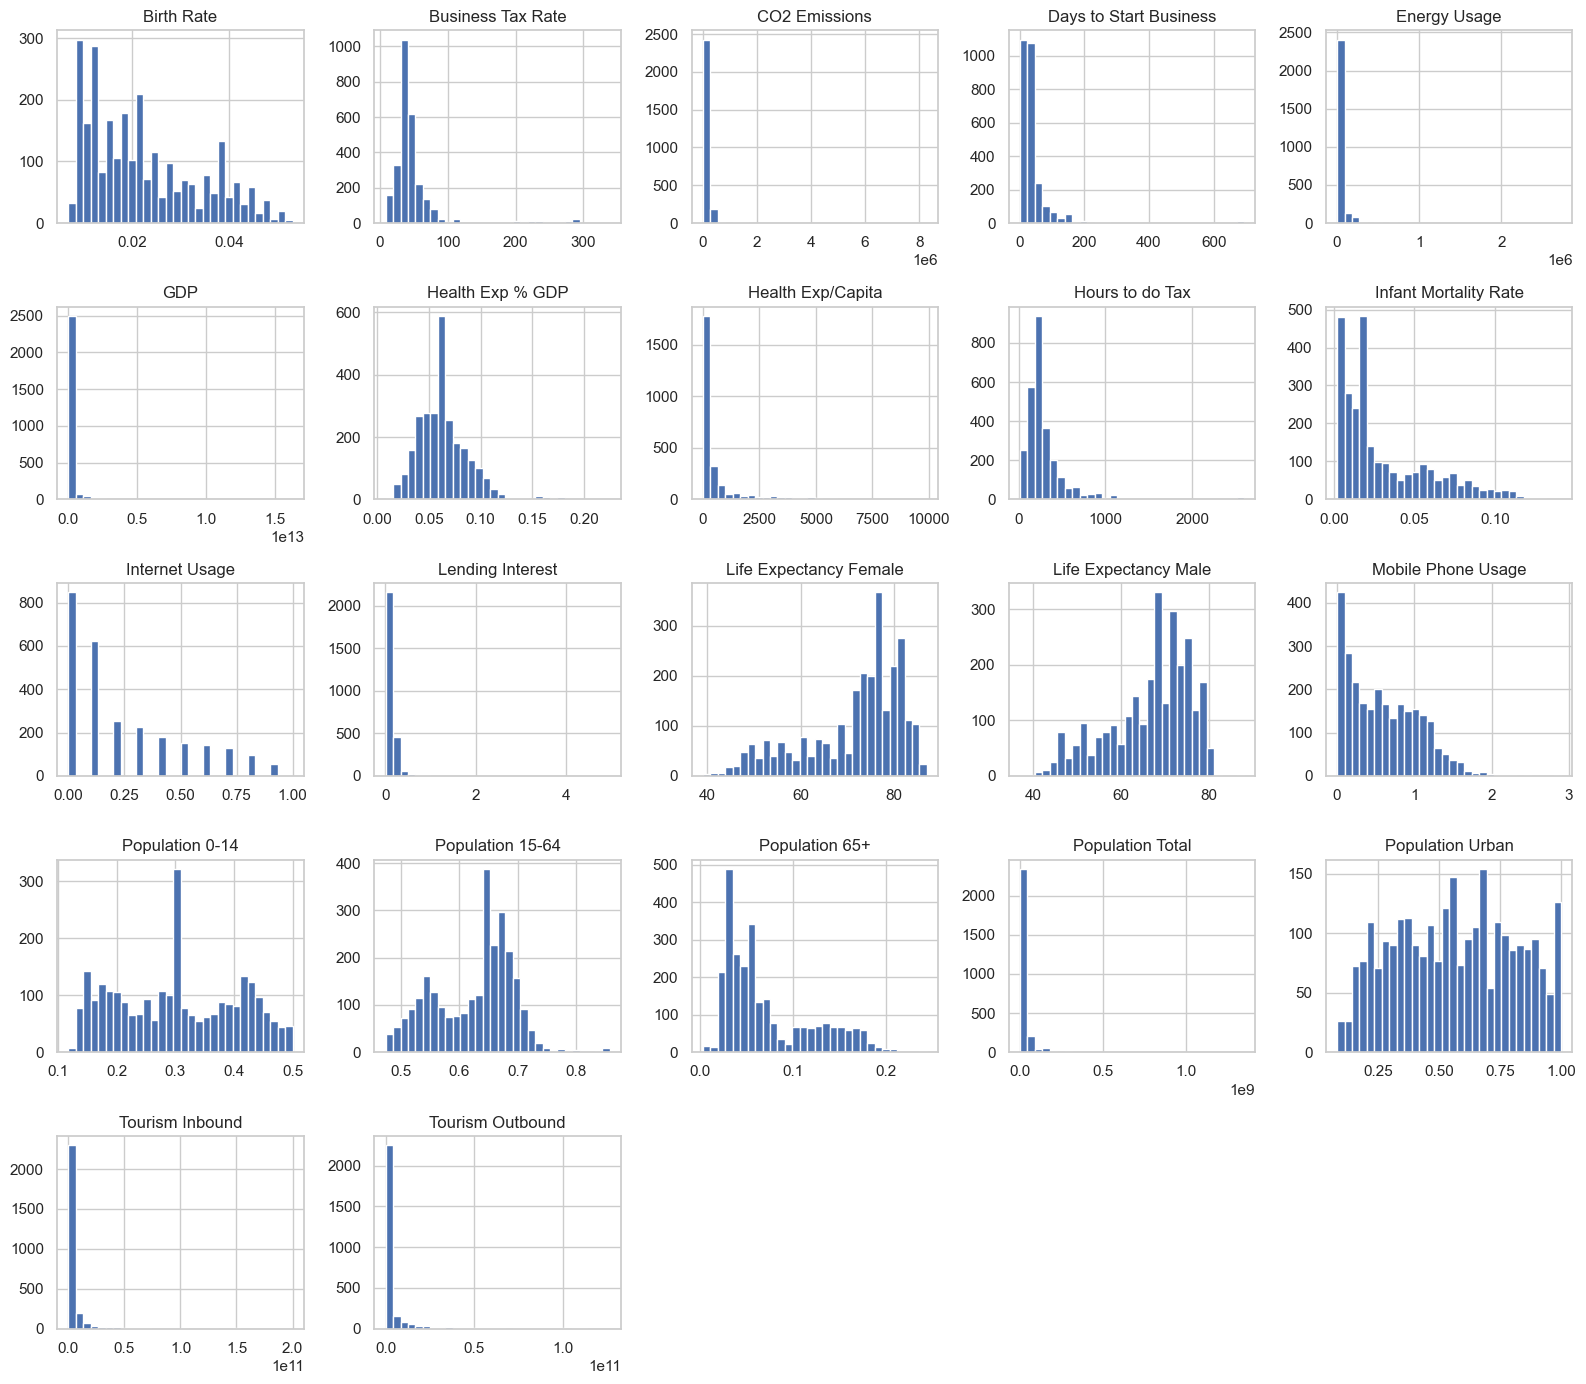

In [55]:
#Plotting the distribution of each numerical feature
df[numeric_cols].hist(figsize=(16, 14), bins=30)
plt.tight_layout()
plt.show()

* Birth Rate: Moderately right-skewed, with most values concentrated at the lower end.
* Business Tax Rate: Highly right-skewed, with most observations at lower tax rates.
* CO2 Emissions: Extremely right-skewed, with most values close to zero and a few very high values.
* Days to Start Business: Highly right-skewed, with most observations at lower values.
* Energy Usage: Extremely right-skewed, with most observations at lower values and a few very large values.
* GDP: Extremely right-skewed, with most observations at lower values and a few very large values.
* Health Exp % GDP: Approximately bell-shaped, with most observations concentrated around the middle.
* Health Exp/Capita: Highly right-skewed, with most observations at lower values.
* Hours to do Tax: Highly right-skewed, with most observations at lower values.
* Infant Mortality Rate: Right-skewed, with most values concentrated at the lower end.
* Internet Usage: Right-skewed, with many observations at lower usage levels.
* Lending Interest: Highly right-skewed, with most values near the lower end.
* Life Expectancy Female: Left-skewed, with most observations concentrated toward higher values.
* Life Expectancy Male: Left-skewed, with most observations concentrated toward higher values.
* Mobile Phone Usage: Moderately right-skewed, with more observations at lower usage levels.
* Population 0-14: Relatively spread across a broad range, with some concentration around certain values.
* Population 15-64: Approximately bell-shaped, with most observations around the middle range.
* Population 65+: Right-skewed, with most observations at lower percentages.
* Population Total: Extremely right-skewed, with most observations at lower population levels.
* Population Urban: Relatively evenly distributed across a broad range, with no strong skewness.
* Tourism Inbound: Extremely right-skewed, with most observations at lower values.
* Tourism Outbound: Extremely right-skewed, with most observations at lower values.

Overall most economic, population, tourism, and business-related variables are right-skewed, while life expectancy variables are left-skewed.

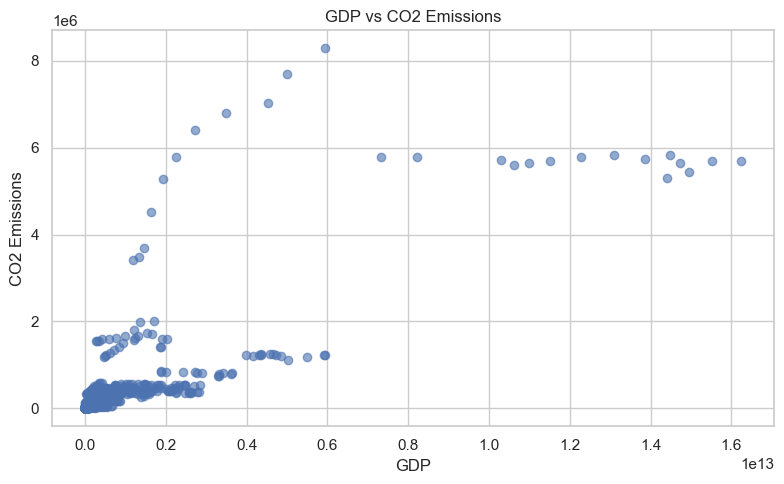

In [56]:
#Plotting the relationship between GDP and CO2 Emissions
plt.figure(figsize=(8, 5))
plt.scatter(df['GDP'], df['CO2 Emissions'], alpha=0.6)
plt.xlabel('GDP')
plt.ylabel('CO2 Emissions')
plt.title('GDP vs CO2 Emissions')
plt.tight_layout()
plt.show()

The plot shows that countries with higher GDP generally have higher CO₂ emissions. Most countries have lower GDP and lower CO₂ emissions, while a few countries have very high values for both.


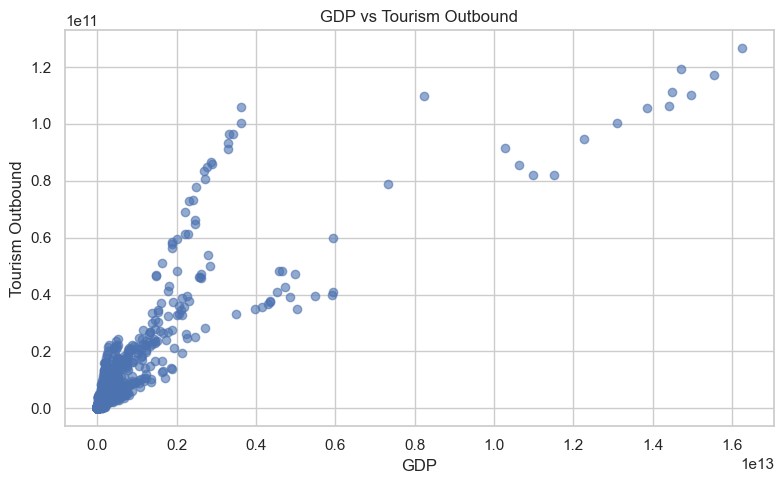

In [57]:
# Plotting the relationship between GDP and Tourism Outbound
plt.figure(figsize=(8, 5))
plt.scatter(df['GDP'], df['Tourism Outbound'], alpha=0.6)
plt.xlabel('GDP')
plt.ylabel('Tourism Outbound')
plt.title('GDP vs Tourism Outbound')
plt.tight_layout()
plt.show()

The plot shows a clear positive relationship between GDP and tourism outbound. Countries with higher GDP generally have higher outbound tourism values. Most of the points follow an upward pattern, although there are some variations.


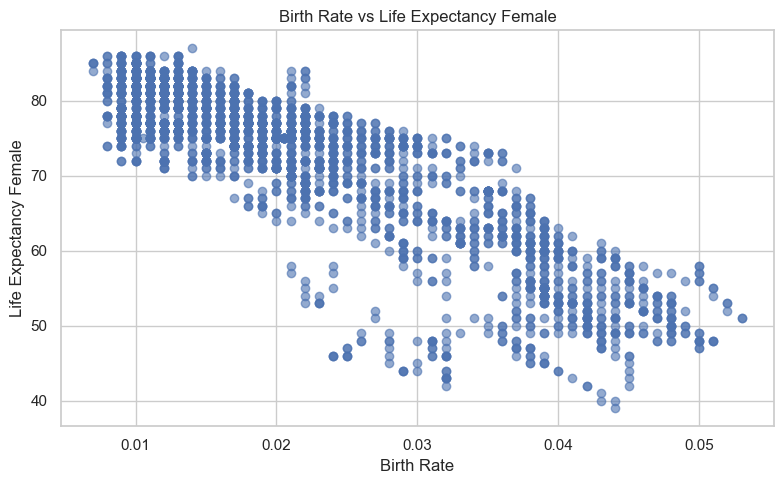

In [58]:
#Plotting the relationship between Birth Rate and Female Life Expectancy
plt.figure(figsize=(8, 5))
plt.scatter(df['Birth Rate'], df['Life Expectancy Female'], alpha=0.6)
plt.xlabel('Birth Rate')
plt.ylabel('Life Expectancy Female')
plt.title('Birth Rate vs Life Expectancy Female')
plt.tight_layout()
plt.show()

The plot shows a clear negative relationship between birth rate and female life expectancy. Countries with higher birth rates generally have lower female life expectancy, while countries with lower birth rates tend to have higher female life expectancy.


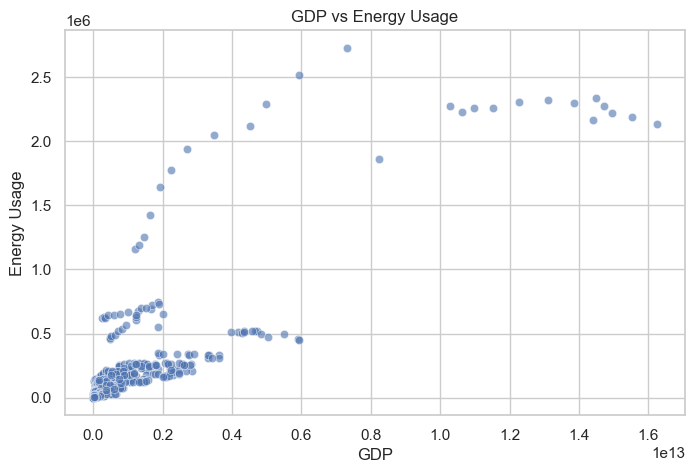

In [59]:
#Scatter plot of GDP vs Energy Usage
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='GDP',
    y='Energy Usage',
    alpha=0.6
)
plt.title('GDP vs Energy Usage')
plt.xlabel('GDP')
plt.ylabel('Energy Usage')
plt.show()

GDP and Energy Usage show a clear positive relationship. As GDP increases, energy usage generally also increases. There is some variation in the data, but the overall trend is upward.

#### Outlier Analysis

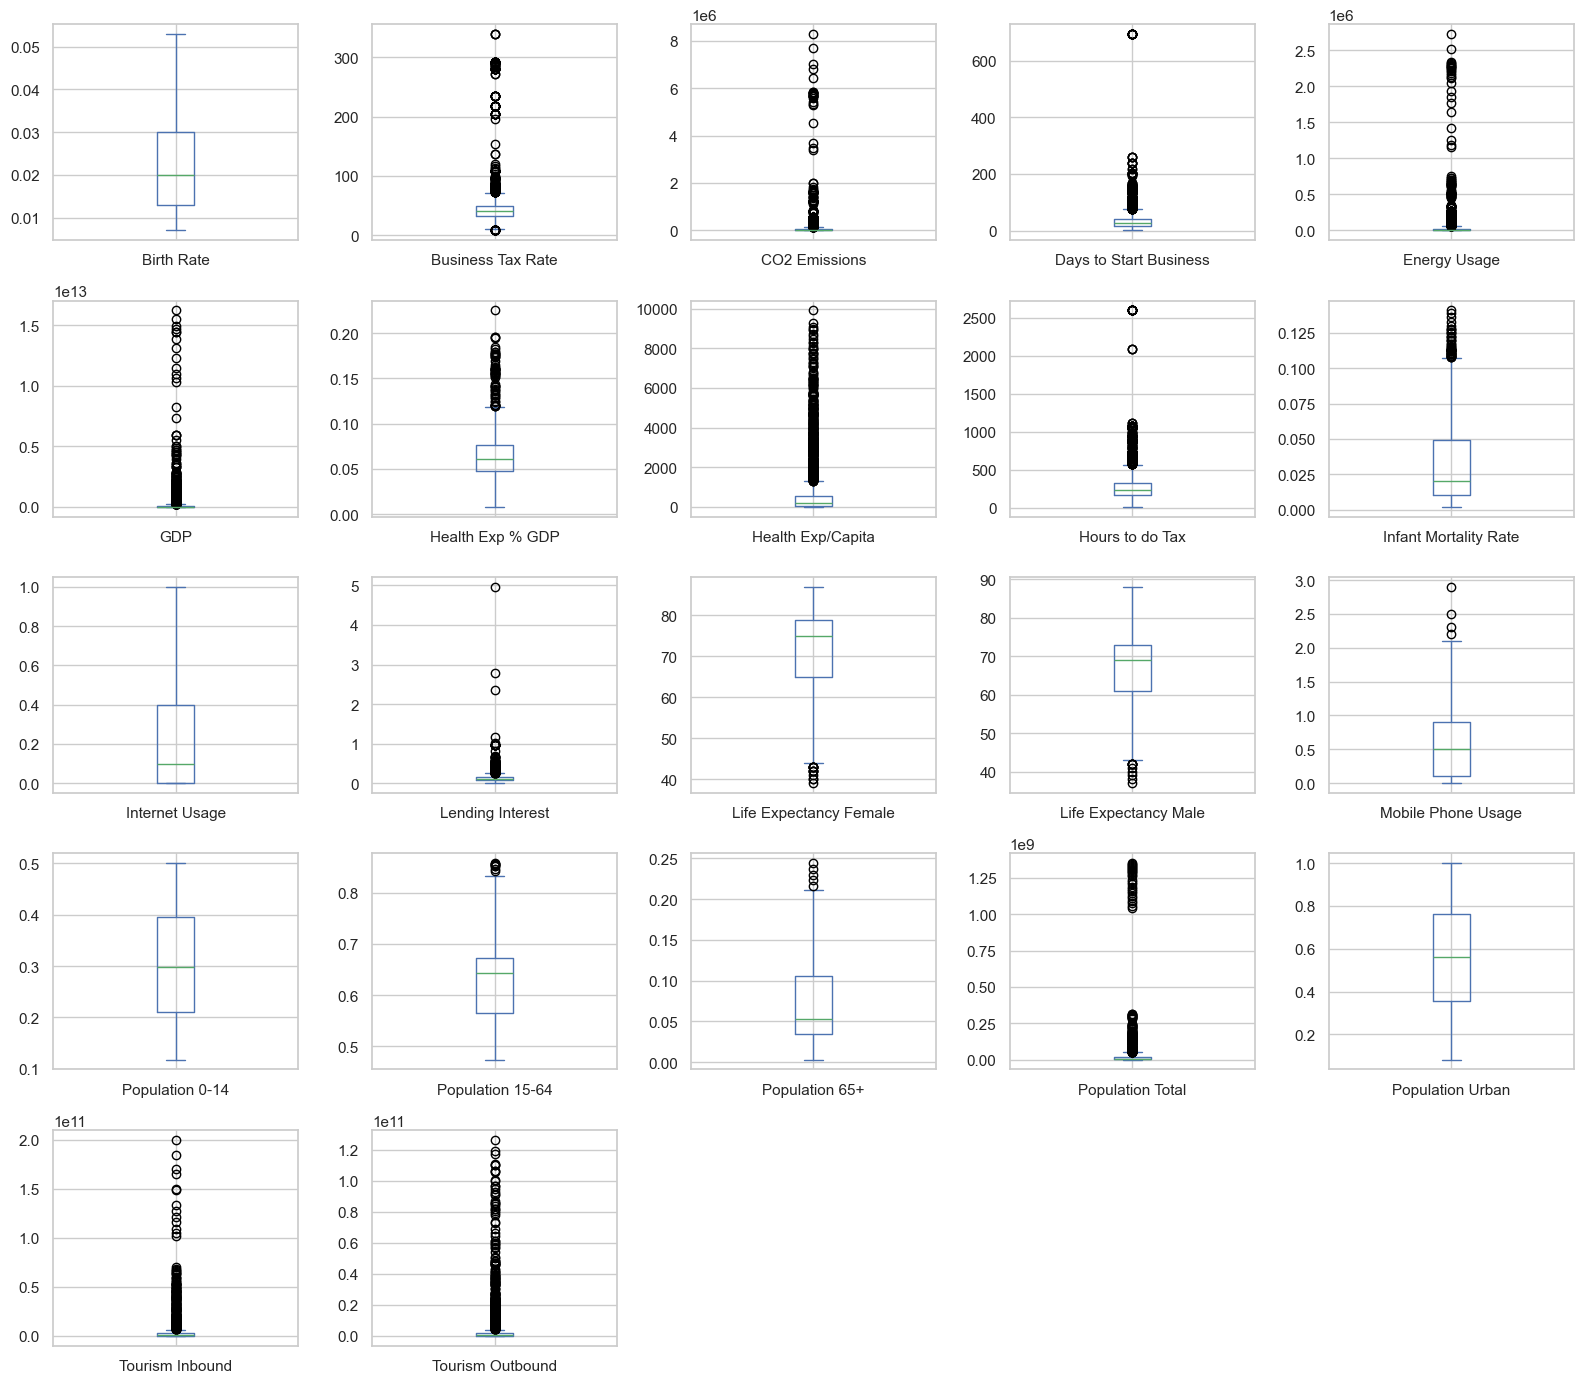

In [60]:
#Plotting boxplots for all numerical features
df[numeric_cols].plot(
    kind='box',
    subplots=True,
    layout=(5, 5),
    figsize=(16, 14)
)
plt.tight_layout()
plt.show()

* Birth Rate: No major outliers are visible, with most values falling within the whiskers.
* Business Tax Rate: Several high-value outliers are present, indicating a few observations with unusually high tax rates.
* CO2 Emissions: Many high-value outliers are visible, showing a strong presence of extreme observations.
* Days to Start Business: Several high-value outliers are present, with some observations far above the main distribution.
* Energy Usage: Numerous high-value outliers are visible, indicating a highly dispersed distribution.
* GDP: A large number of high-value outliers are present, with the distribution heavily concentrated at lower values.
* Health Exp % GDP: Several high-value outliers are visible above the upper whisker.
* Health Exp/Capita: Many high-value outliers are present, with a long upper tail.
* Hours to do Tax: Several high-value outliers are visible above the upper whisker.
* Infant Mortality Rate: Several high-value outliers are present above the main distribution.
* Internet Usage: No significant outliers are clearly visible.
* Lending Interest: Several high-value outliers are visible, including some extreme observations.
* Life Expectancy Female: A few low-value outliers are present below the lower whisker.
* Life Expectancy Male: A few low-value outliers are present below the lower whisker.
* Mobile Phone Usage: A few high-value outliers are visible above the upper whisker.
* Population 0-14: No major outliers are clearly visible.
* Population 15-64: A few high-value outliers are visible.
* Population 65+: Several high-value outliers are present above the upper whisker.
* Population Total: Many high-value outliers are visible, indicating a highly dispersed distribution.
* Population Urban: No major outliers are clearly visible.
* Tourism Inbound: Numerous high-value outliers are present, with several extreme observations.
* Tourism Outbound: Numerous high-value outliers are present, with several extreme observations.

Overall, several features have some outliers, especially economic, population, emissions, energy, and tourism-related features. However, these high values may be normal because some countries have much larger populations, economies, emissions, energy use, or tourism activity.

So, we did not remove or cap these outliers directly. Instead, we considered suitable transformations to reduce their effect on the clustering results.

#### Transformation

Skewness helps us check whether the data is evenly distributed or if it is more spread towards one side.

First, we identified features with an absolute skewness value of 1 or more. These features were considered for further checking.

For the actual log transformation, we used a stricter condition of an absolute skewness value greater than 2. This helps us avoid transforming features that have only moderate skewness.


In [61]:
#Selecting features with absolute skewness greater than or equal to 1
highly_skewed = skewness[abs(skewness) >= 1]
highly_skewed

Infant Mortality Rate      1.049118
Health Exp % GDP           1.165093
Health Exp/Capita          2.824485
Business Tax Rate          4.313881
Hours to do Tax            4.459112
Tourism Outbound           5.419234
Tourism Inbound            7.337378
Days to Start Business     7.445885
Energy Usage               7.606211
CO2 Emissions              8.622398
Population Total           8.788164
GDP                        9.548553
Lending Interest          14.644518
dtype: float64

In [62]:
#Checking for zero and negative values in highly skewed features
df[highly_skewed.index].min().sort_values()

Infant Mortality Rate     2.000000e-03
Lending Interest          5.000000e-03
Health Exp % GDP          8.000000e-03
Days to Start Business    1.000000e+00
Health Exp/Capita         2.000000e+00
CO2 Emissions             7.000000e+00
Energy Usage              8.000000e+00
Business Tax Rate         8.200000e+00
Hours to do Tax           1.200000e+01
Population Total          1.887600e+04
Tourism Outbound          2.000000e+05
Tourism Inbound           7.000000e+05
GDP                       6.310127e+07
dtype: float64

**Skewness Threshold and Log Transformation**

Features with an absolute skewness value greater than 2 are considered highly skewed, so we selected them for transformation. Features below this value were kept as they were to avoid unnecessary changes.

Since all the selected features have positive values, we applied a natural log (`log`) transformation. The log transformation reduces the effect of very large values and helps make the data more balanced.

This helps reduce skewness and makes the features more suitable for clustering, where very large values can have a strong effect on the results.

In [63]:
#Selecting features with absolute skewness greater than 2
transform_cols = skewness[abs(skewness) > 2].index

#Applying natural logarithmic transformation to highly skewed features
df[transform_cols] = np.log(df[transform_cols])

In [64]:
#Recalculating the skewness of all numerical features after transformation
skewness_after = df[numeric_cols].skew().sort_values()
skewness_after

Life Expectancy Female   -0.949906
Life Expectancy Male     -0.757111
Energy Usage             -0.602268
Population Total         -0.371789
Hours to do Tax          -0.270404
Population 15-64         -0.264664
Tourism Inbound          -0.235389
Tourism Outbound          0.000398
Population Urban          0.012928
CO2 Emissions             0.041983
Days to Start Business    0.045916
Population 0-14           0.077170
Lending Interest          0.134874
Health Exp/Capita         0.183106
GDP                       0.273278
Business Tax Rate         0.603614
Mobile Phone Usage        0.611970
Birth Rate                0.704268
Internet Usage            1.008251
Population 65+            1.035586
Infant Mortality Rate     1.195218
Health Exp % GDP          1.273000
dtype: float64

In [65]:
#Comparing skewness values before and after logarithmic transformation
skewness_comparison = pd.DataFrame({
    'Before Transformation': skewness,
    'After Transformation': skewness_after
})
skewness_comparison['Change'] = (
    skewness_comparison['After Transformation']
    - skewness_comparison['Before Transformation']
)
skewness_comparison.sort_values(
    'Before Transformation',
    key=abs,
    ascending=False
)

,Before Transformation,After Transformation,Change
Lending Interest,14.644518,0.134874,-14.509645
GDP,9.548553,0.273278,-9.275276
Population Total,8.788164,-0.371789,-9.159953
CO2 Emissions,8.622398,0.041983,-8.580416
Energy Usage,7.606211,-0.602268,-8.208480
Days to Start Business,7.445885,0.045916,-7.399969
Tourism Inbound,7.337378,-0.235389,-7.572767
Tourism Outbound,5.419234,0.000398,-5.418836
Hours to do Tax,4.459112,-0.270404,-4.729516
Business Tax Rate,4.313881,0.603614,-3.710267


#### Post Transformation Plots

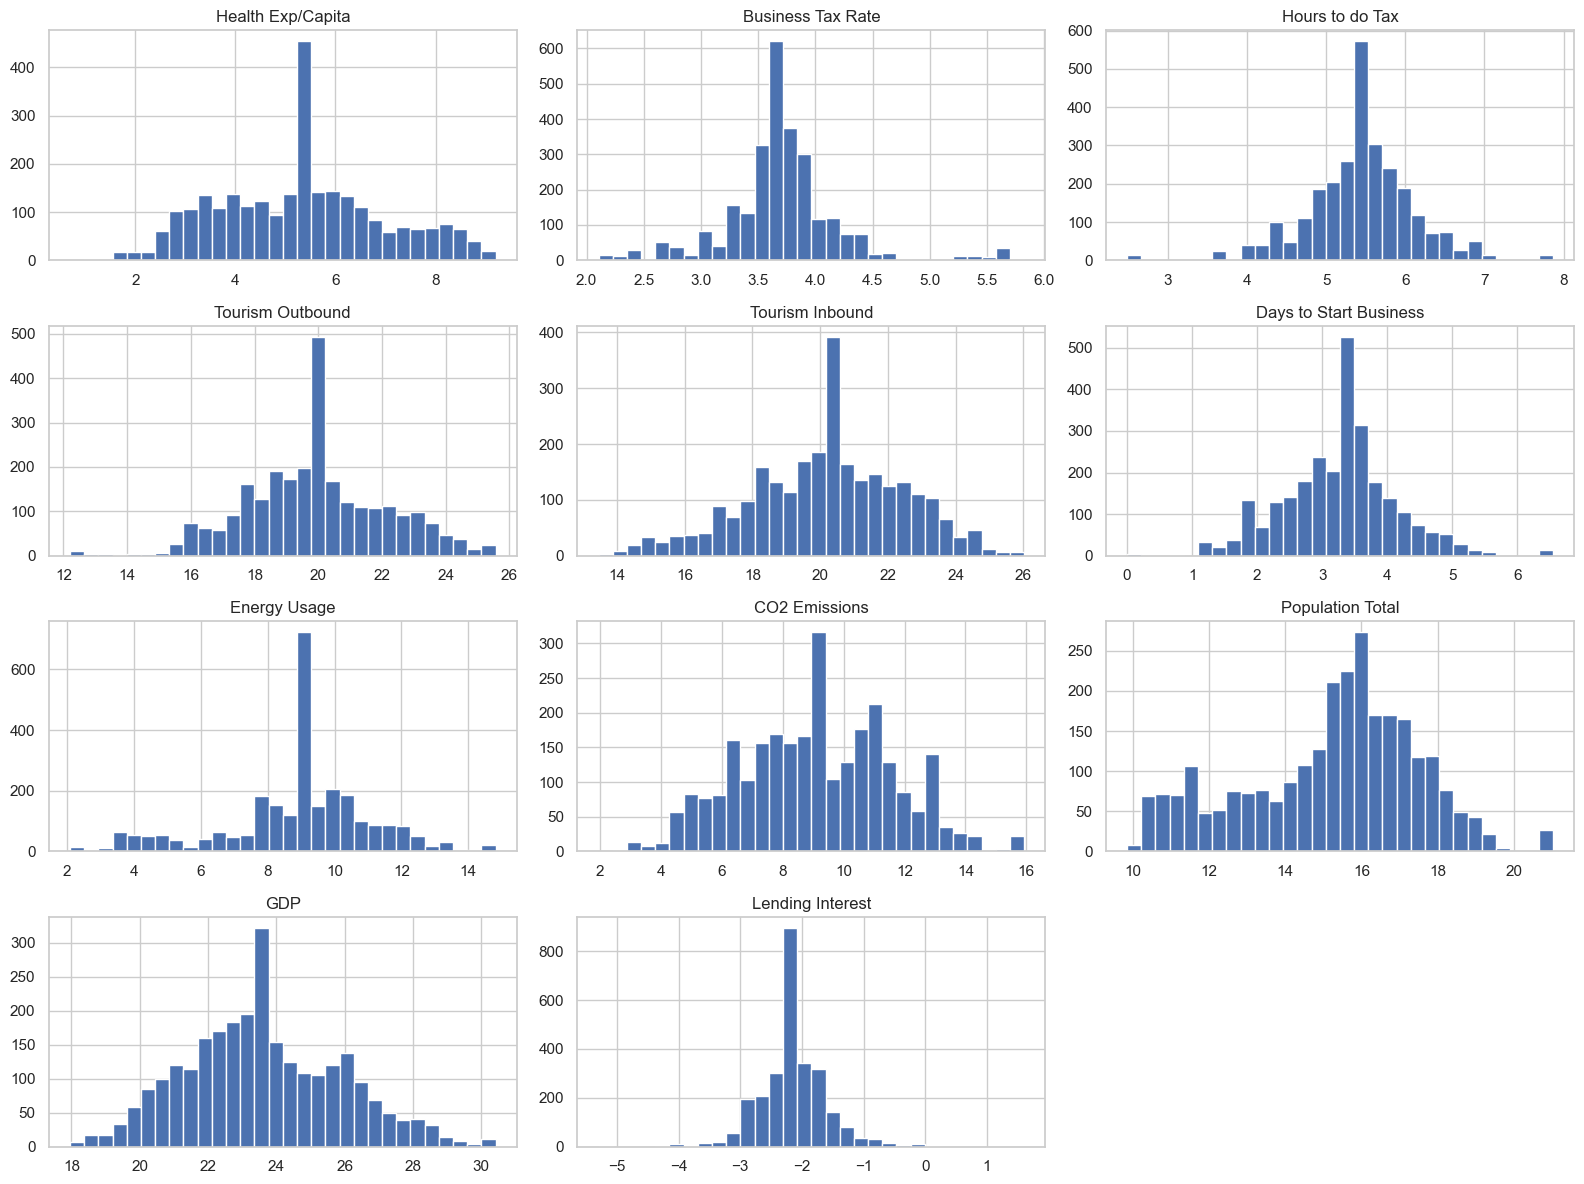

In [66]:
#Plotting histograms for the transformed features
df[transform_cols].hist(
    figsize=(16, 12),
    bins=30
)
plt.tight_layout()
plt.show()

The logarithmic transformation substantially reduced the right-skewness of the selected features by compressing extreme values. Most of the transformed distributions are now more balanced, reducing the influence of extreme observations and making the features more suitable for distance-based clustering.

In [67]:
#Selecting numerical features except 'Number of Records'
correlation_cols = df.select_dtypes(include='number').columns.drop('Number of Records')

#Calculating the correlation matrix
correlation_matrix = df[correlation_cols].corr()

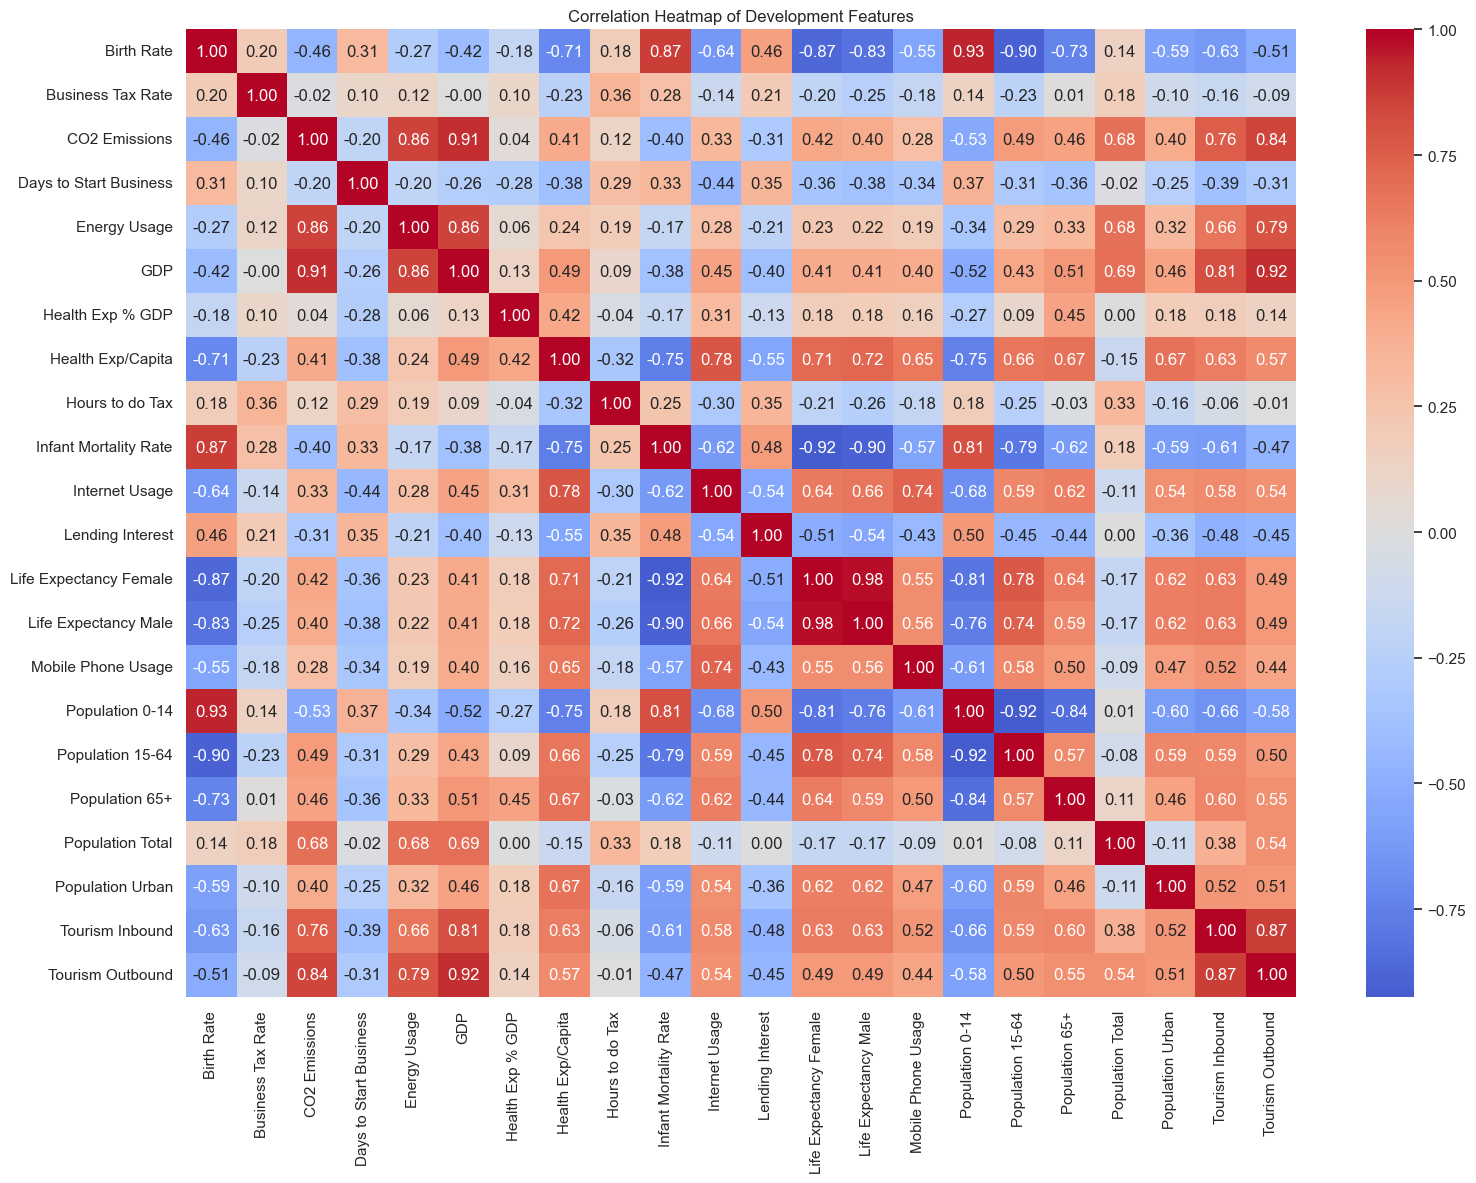

In [68]:
#Plotting the correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Heatmap of Development Features')
plt.tight_layout()
plt.show()

* Female and male life expectancy have a very strong positive correlation (0.98).
* GDP is strongly related to CO2 emissions (0.91), energy usage (0.86), and tourism outbound (0.92).
* Birth rate has a strong negative relationship with both female (-0.87) and male (-0.83) life expectancy.
* The 0–14 age group is strongly related to birth rate (0.93) and has a strong negative correlation with the 15–64 age group (-0.92).
* Health expenditure per capita also has a strong positive relationship with internet usage (0.78) and male life expectancy (0.72).

Overall, the heatmap shows that many economic, population, and health-related features are closely related to each other.

#### Clustering Preparation

**Country-Level Aggregation**

Our dataset has 2,704 rows for 208 countries. Each country has 13 observations.

Since our goal is to group countries based on their development and economic features, we need only one row for each country. So, we grouped the data by country and took the median value of each numerical feature.

We used the median because it is less affected by extreme values and gives a good overall value for each country.

After this step, the dataset was reduced from 2,704 rows to 208 rows, with one row representing each country.

In [69]:
#Grouping the data by country and calculating the median of each numerical feature
df_country = df.groupby('Country').median(numeric_only=True)

In [70]:
#Checking the shape of the country-level dataset
df_country.shape

(208, 23)

In [71]:
#Removing the non-informative Number of Records column from the country-level dataset
df_clustering = df_country.drop('Number of Records', axis=1)

In [72]:
#Checking the shape of the final clustering dataset
df_clustering.shape

(208, 22)

In [73]:
#Checking for missing values in the final clustering dataset
df_clustering.isnull().sum().sum()

np.int64(0)

In [74]:
#Checking the data types of the clustering features
df_clustering.dtypes

Birth Rate                float64
Business Tax Rate         float64
CO2 Emissions             float64
Days to Start Business    float64
Energy Usage              float64
GDP                       float64
Health Exp % GDP          float64
Health Exp/Capita         float64
Hours to do Tax           float64
Infant Mortality Rate     float64
Internet Usage            float64
Lending Interest          float64
Life Expectancy Female    float64
Life Expectancy Male      float64
Mobile Phone Usage        float64
Population 0-14           float64
Population 15-64          float64
Population 65+            float64
Population Total          float64
Population Urban          float64
Tourism Inbound           float64
Tourism Outbound          float64
dtype: object

In [75]:
#Creating a StandardScaler object
scaler = StandardScaler()

#Standardizing the country-level clustering features
df_scaled = scaler.fit_transform(df_clustering)

#Converting the scaled data back to a DataFrame
df_scaled = pd.DataFrame(
    df_scaled,
    columns=df_clustering.columns,
    index=df_clustering.index
)

In [76]:
#Checking the shape of the scaled dataset
df_scaled.shape

(208, 22)

In [77]:
#Checking the final clustering dataset dimensions and missing values
print("Country-level dataset:", df_country.shape)
print("Clustering dataset:", df_clustering.shape)
print("Scaled dataset:", df_scaled.shape)
print("Missing values:", df_scaled.isnull().sum().sum())

Country-level dataset: (208, 23)
Clustering dataset: (208, 22)
Scaled dataset: (208, 22)
Missing values: 0


### Model Building(Baseline)

**Model Evaluation Metrics**

The tuned clustering models are evaluated using three main clustering metrics:

- Silhouette Score: Measures how well each country fits within its assigned cluster compared with other clusters. Higher values are preferred.
- Davies-Bouldin Index: Measures the similarity between clusters. Lower values indicate better separation between clusters.
- Calinski-Harabasz Score: Measures the separation and compactness of clusters. Higher values generally indicate better-defined clusters.

These metrics are considered together rather than relying on a single metric when comparing the clustering models.

#### K-Means

In [78]:
#Creating the baseline K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

In [79]:
#Fitting the model on the scaled clustering data
kmeans.fit(df_scaled)
#Getting the cluster labels
kmeans_labels = kmeans.labels_
#Adding cluster labels to the country-level dataset
df_clustering['KMeans_Cluster'] = kmeans_labels
#Displaying the number of countries in each cluster
df_clustering['KMeans_Cluster'].value_counts().sort_index()

C:\Users\Manthan\.anaconda\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans_Cluster
0    67
1    86
2    55
Name: count, dtype: int64

In [80]:
#Calculating baseline K-Means evaluation metrics
base_kmeans_silhouette = silhouette_score(df_scaled, kmeans_labels)
base_kmeans_davies_bouldin = davies_bouldin_score(df_scaled, kmeans_labels)
base_kmeans_calinski_harabasz = calinski_harabasz_score(df_scaled, kmeans_labels)

In [81]:
print("Baseline K-Means Scores")
print("----------------------")
print("Silhouette Score:", round(base_kmeans_silhouette, 4))
print("Davies-Bouldin Index:", round(base_kmeans_davies_bouldin, 4))
print("Calinski-Harabasz Score:", round(base_kmeans_calinski_harabasz, 4))

Baseline K-Means Scores
----------------------
Silhouette Score: 0.2247
Davies-Bouldin Index: 1.5182
Calinski-Harabasz Score: 90.4426


#### Agglomeratrive Clustering

In [82]:
#Creating the baseline Agglomerative Clustering model
agglomerative = AgglomerativeClustering(n_clusters=3,linkage='ward')

In [83]:
# Fitting the model
agglomerative_labels = agglomerative.fit_predict(df_scaled)
# Adding cluster labels to the country-level dataset
df_clustering['Agglomerative_Cluster'] = agglomerative_labels
# Displaying the number of countries in each cluster
df_clustering['Agglomerative_Cluster'].value_counts().sort_index()

Agglomerative_Cluster
0    111
1     57
2     40
Name: count, dtype: int64

In [84]:
#Calculating baseline Agglomerative Clustering evaluation metrics
base_agglomerative_silhouette = silhouette_score(df_scaled,agglomerative_labels)
base_agglomerative_davies_bouldin = davies_bouldin_score(df_scaled,agglomerative_labels)
base_agglomerative_calinski_harabasz = calinski_harabasz_score(df_scaled,agglomerative_labels)

In [85]:
print("Baseline Agglomerative Clustering Scores")
print("----------------------------------------")
print("Silhouette Score:", round(base_agglomerative_silhouette, 4))
print("Davies-Bouldin Index:", round(base_agglomerative_davies_bouldin, 4))
print("Calinski-Harabasz Score:", round(base_agglomerative_calinski_harabasz, 4))

Baseline Agglomerative Clustering Scores
----------------------------------------
Silhouette Score: 0.2119
Davies-Bouldin Index: 1.4168
Calinski-Harabasz Score: 79.9711


#### Gaussian Mixture Model

In [86]:
# Creating the baseline GMM model
gmm = GaussianMixture(n_components=3,random_state=42)
#Fitting the model
gmm.fit(df_scaled)

C:\Users\Manthan\.anaconda\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [87]:
#Getting cluster labels
gmm_labels = gmm.predict(df_scaled)
#Adding cluster labels to the country-level dataset
df_clustering['GMM_Cluster'] = gmm_labels
#Displaying the number of countries in each cluster
df_clustering['GMM_Cluster'].value_counts().sort_index()

GMM_Cluster
0    72
1    72
2    64
Name: count, dtype: int64

In [88]:
#Calculating baseline GMM evaluation metrics
base_gmm_silhouette = silhouette_score(df_scaled,gmm_labels)
base_gmm_davies_bouldin = davies_bouldin_score(df_scaled,gmm_labels)
base_gmm_calinski_harabasz = calinski_harabasz_score(df_scaled,gmm_labels)

In [89]:
print("Baseline GMM Scores")
print("------------------")
print("Silhouette Score:", round(base_gmm_silhouette, 4))
print("Davies-Bouldin Index:", round(base_gmm_davies_bouldin, 4))
print("Calinski-Harabasz Score:", round(base_gmm_calinski_harabasz, 4))

Baseline GMM Scores
------------------
Silhouette Score: 0.1968
Davies-Bouldin Index: 1.693
Calinski-Harabasz Score: 84.0269


#### DBSCAN

In [90]:
#Creating the baseline DBSCAN model
dbscan = DBSCAN(eps=0.5,min_samples=5)
#Fitting the model and getting cluster labels
dbscan_labels = dbscan.fit_predict(df_scaled)

In [91]:
#Adding cluster labels to the country-level dataset
df_clustering['DBSCAN_Cluster'] = dbscan_labels
#Displaying the number of countries in each cluster
df_clustering['DBSCAN_Cluster'].value_counts().sort_index()

DBSCAN_Cluster
-1    208
Name: count, dtype: int64

In [92]:
#Calculating baseline DBSCAN evaluation metrics
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

In [93]:
print("Baseline DBSCAN Results")
print("----------------------")
print("Number of Clusters:", n_clusters)
print("Number of Noise Points:", n_noise)

Baseline DBSCAN Results
----------------------
Number of Clusters: 0
Number of Noise Points: 208


In [94]:
if n_clusters >= 2:
    base_dbscan_silhouette = silhouette_score(df_scaled,dbscan_labels)
    base_dbscan_davies_bouldin = davies_bouldin_score(df_scaled,dbscan_labels)
    base_dbscan_calinski_harabasz = calinski_harabasz_score(df_scaled,dbscan_labels)
    print("Silhouette Score:", round(base_dbscan_silhouette, 4))
    print("Davies-Bouldin Index:", round(base_dbscan_davies_bouldin, 4))
    print("Calinski-Harabasz Score:", round(base_dbscan_calinski_harabasz, 4))
else:
    base_dbscan_silhouette = None
    base_dbscan_davies_bouldin = None
    base_dbscan_calinski_harabasz = None
    print("Not enough clusters to calculate evaluation metrics.")

Not enough clusters to calculate evaluation metrics.


### Tuning Models

**Model Tuning and Selection Criteria**

- Higher Silhouette Score indicates better-defined and well-separated clusters.
- Lower Davies-Bouldin Index indicates better cluster separation and compactness.
- Higher Calinski-Harabasz Score indicates better-defined clusters.
- Cluster sizes should be reasonably balanced and should represent meaningful groups of countries.
- For DBSCAN, the number of noise points should also be considered.
- The final model will be selected by considering both the evaluation metrics and the practical interpretation of the resulting clusters.

#### k-Means

In [95]:
#Lists to store results
k_values = []
inertia_scores = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

In [96]:
#Testing K from 2 to 10
for k in range(2, 11):
    kmeans_model = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = kmeans_model.fit_predict(df_scaled)

    k_values.append(k)
    inertia_scores.append(kmeans_model.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(df_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(df_scaled, labels))

#Creating results DataFrame
kmeans_tuning_results = pd.DataFrame({
    'K': k_values,
    'Inertia': inertia_scores,
    'Silhouette': silhouette_scores,
    'Davies-Bouldin': davies_bouldin_scores,
    'Calinski-Harabasz': calinski_harabasz_scores
})

C:\Users\Manthan\.anaconda\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Manthan\.anaconda\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Manthan\.anaconda\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Manthan\.anaconda\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

In [97]:
kmeans_tuning_results

,K,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,2936.188817,0.303739,1.247658,115.047473
1,3,2430.981742,0.224744,1.518186,90.442626
2,4,2124.770146,0.228763,1.423667,78.447841
3,5,1932.780116,0.214730,1.481081,69.404382
4,6,1826.646216,0.196353,1.641452,60.807556
5,7,1733.555055,0.186600,1.520475,54.928689
6,8,1647.767475,0.179845,1.600861,50.774025
7,9,1571.556602,0.144726,1.703487,47.555099
8,10,1489.926387,0.155492,1.650789,45.568439


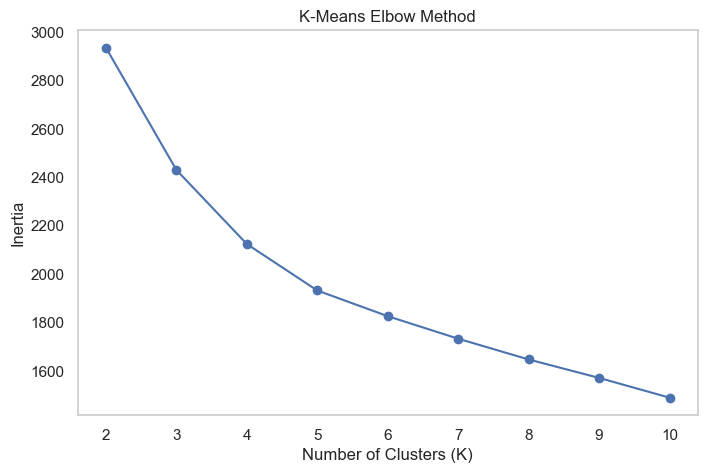

In [98]:
#Plotting Silhouette Scores for K-Means
plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_tuning_results['K'],
    kmeans_tuning_results['Inertia'],
    marker='o'
)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('K-Means Elbow Method')
plt.xticks(range(2, 11))
plt.grid()
plt.show()

The inertia decreases as the number of clusters increases. A large decrease can be seen from K=2 to K=3 and K=3 to K=4, after which the decrease becomes more gradual. The elbow is not very sharp, but K=2 appears to be a reasonable choice when considered along with the other evaluation metrics.

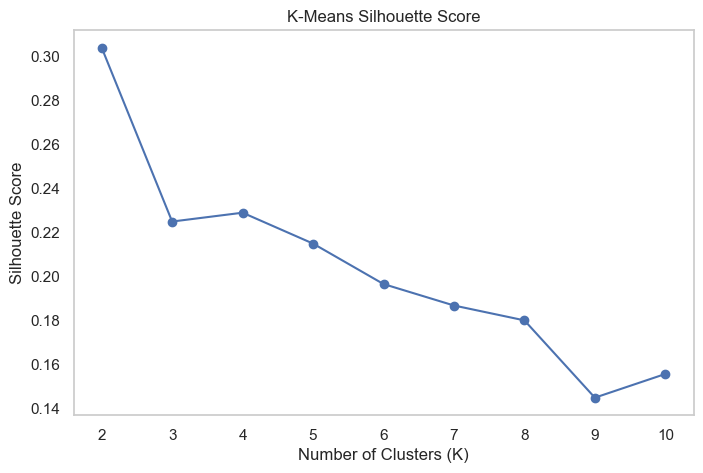

In [99]:
#Plotting Silhouette Scores for K-Means
plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_tuning_results['K'],
    kmeans_tuning_results['Silhouette'],
    marker='o'
)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('K-Means Silhouette Score')
plt.xticks(range(2, 11))
plt.grid()
plt.show()

The Silhouette Score is highest at K=2 with a value of approximately 0.304. After K=2, the score decreases considerably and generally continues to decrease as the number of clusters increases. Therefore, based on the Silhouette Score, K=2 appears to provide better-separated clusters among the tested values.

The elbow method showed that the curve starts to flatten around **K=4**. However, the silhouette score was highest for **K=2**, which means the two clusters are better separated. Since K=2 also makes the country groups easier to understand and interpret, **K=2** was selected for the final K-Means model.


In [100]:
#Creating the tuned K-Means model
tuned_kmeans_model = KMeans(n_clusters=2,random_state=42,n_init=10)
#Fitting the tuned model
tuned_kmeans_labels = tuned_kmeans_model.fit_predict(df_scaled)
#Storing the cluster labels
df_clustering['Tuned_KMeans_Cluster'] = tuned_kmeans_labels

C:\Users\Manthan\.anaconda\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [101]:
# Calculating tuned K-Means evaluation metrics
tuned_kmeans_silhu = silhouette_score(df_scaled,tuned_kmeans_labels)
tuned_kmeans_db = davies_bouldin_score(df_scaled,tuned_kmeans_labels)
tuned_kmeans_ch = calinski_harabasz_score(df_scaled,tuned_kmeans_labels)

In [102]:
print("Tuned K-Means Results")
print("--------------------")
print("Number of Clusters:", 2)
print("Silhouette Score:", round(tuned_kmeans_silhu, 4))
print("Davies-Bouldin Index:", round(tuned_kmeans_db, 4))
print("Calinski-Harabasz Score:", round(tuned_kmeans_ch, 4))

Tuned K-Means Results
--------------------
Number of Clusters: 2
Silhouette Score: 0.3037
Davies-Bouldin Index: 1.2477
Calinski-Harabasz Score: 115.0475


#### Agglomerative Clustering

In [103]:
#Lists to store tuning results
agglomerative_results = []

In [104]:
#Test different numbers of clusters and linkage methods
for linkage in ['ward', 'complete', 'average']:
    for k in range(2, 11):
        #Ward linkage only supports Euclidean distance
        model = AgglomerativeClustering(n_clusters=k,linkage=linkage)
        labels = model.fit_predict(df_scaled)
        #Calculating evaluation metrics
        silhouette = silhouette_score(df_scaled, labels)
        davies_bouldin = davies_bouldin_score(df_scaled, labels)
        calinski_harabasz = calinski_harabasz_score(df_scaled, labels)
        #Storing results
        agglomerative_results.append({
            'Linkage': linkage,
            'K': k,
            'Silhouette': silhouette,
            'Davies-Bouldin': davies_bouldin,
            'Calinski-Harabasz': calinski_harabasz
        })
#Converting results to DataFrame
agglomerative_tuning_results = pd.DataFrame(agglomerative_results)

In [105]:
agglomerative_tuning_results

,Linkage,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,ward,2,0.286817,1.201903,92.158719
1,ward,3,0.211911,1.416797,79.971144
2,ward,4,0.208930,1.446267,71.204687
3,ward,5,0.200726,1.552998,64.860303
4,ward,6,0.206111,1.441228,56.793446
5,ward,7,0.182085,1.492161,51.468327
6,ward,8,0.166632,1.538763,48.037414
7,ward,9,0.159503,1.624483,45.037353
8,ward,10,0.139568,1.724285,42.779434
9,complete,2,0.292745,1.299113,104.980685


In [106]:
print("Best Silhouette:")
print(
    agglomerative_tuning_results.loc[
        agglomerative_tuning_results['Silhouette'].idxmax()
    ]
)
print("\nBest Davies-Bouldin:")
print(
    agglomerative_tuning_results.loc[
        agglomerative_tuning_results['Davies-Bouldin'].idxmin()
    ]
)
print("\nBest Calinski-Harabasz:")
print(
    agglomerative_tuning_results.loc[
        agglomerative_tuning_results['Calinski-Harabasz'].idxmax()
    ]
)

Best Silhouette:
Linkage               average
K                           2
Silhouette           0.304166
Davies-Bouldin       0.550722
Calinski-Harabasz    2.964555
Name: 18, dtype: object

Best Davies-Bouldin:
Linkage               average
K                           2
Silhouette           0.304166
Davies-Bouldin       0.550722
Calinski-Harabasz    2.964555
Name: 18, dtype: object

Best Calinski-Harabasz:
Linkage                complete
K                             2
Silhouette             0.292745
Davies-Bouldin         1.299113
Calinski-Harabasz    104.980685
Name: 9, dtype: object


In [107]:
#Checking cluster sizes for average linkage with K=2
average_k2 = AgglomerativeClustering(n_clusters=2,linkage='average')
average_k2_labels = average_k2.fit_predict(df_scaled)
print(pd.Series(average_k2_labels).value_counts().sort_index())
print("Unique clusters:", np.unique(average_k2_labels))

0    207
1      1
Name: count, dtype: int64
Unique clusters: [0 1]


Although Average linkage with K=2 gives the highest Silhouette Score (0.3042) and the lowest Davies-Bouldin Index (0.5507), the resulting clusters are highly unbalanced. One cluster contains 207 countries, while the other contains only 1 country. This means the model is essentially separating one country from all the others rather than forming two meaningful groups. Therefore, Average linkage with K=2 is not considered suitable for the final model.

In [108]:
# Creating the tuned Agglomerative Clustering model
tuned_agglomerative_model = AgglomerativeClustering(n_clusters=2,linkage='complete')

In [109]:
#Fitting the tuned model
tuned_agglomerative_labels = tuned_agglomerative_model.fit_predict(df_scaled)
#Storing the tuned cluster labels
df_clustering['Tuned_Agglomerative_Cluster'] = tuned_agglomerative_labels

In [110]:
#Calculating tuned Agglomerative evaluation metrics
tuned_agglomerative_silhu = silhouette_score(df_scaled,tuned_agglomerative_labels)
tuned_agglomerative_db = davies_bouldin_score(df_scaled,tuned_agglomerative_labels)
tuned_agglomerative_ch = calinski_harabasz_score(df_scaled,tuned_agglomerative_labels)

In [111]:
print("Tuned Agglomerative Results")
print("---------------------------")
print("Number of Clusters:", 2)
print("Linkage:", "complete")
print("Silhouette Score:", round(tuned_agglomerative_silhu, 4))
print("Davies-Bouldin Index:", round(tuned_agglomerative_db, 4))
print("Calinski-Harabasz Score:", round(tuned_agglomerative_ch, 4))

Tuned Agglomerative Results
---------------------------
Number of Clusters: 2
Linkage: complete
Silhouette Score: 0.2927
Davies-Bouldin Index: 1.2991
Calinski-Harabasz Score: 104.9807


In [112]:
print("Cluster Distribution:")
print(pd.Series(tuned_agglomerative_labels).value_counts().sort_index())

Cluster Distribution:
0     76
1    132
Name: count, dtype: int64


The tuned Agglomerative model with Complete linkage and 2 clusters divides the 208 countries into two groups containing 76 and 132 countries. The clusters are relatively balanced compared with the Average linkage result, which placed 207 countries in one cluster and only 1 country in the other. Therefore, the selected configuration provides a more meaningful distribution of countries across the two clusters.

#### Gaussian Mixture Model

In [113]:
#Storing GMM tuning results
gmm_results = []

In [114]:
#Testing different covariance types and number of components
for covariance_type in ['full', 'tied', 'diag', 'spherical']:
    for n in range(2, 11):
        #Creating GMM model
        model = GaussianMixture(n_components=n,covariance_type=covariance_type,random_state=42)
        #Fitting model
        model.fit(df_scaled)
        #Getting cluster labels
        labels = model.predict(df_scaled)
        #Calculating metrics
        silhouette = silhouette_score(df_scaled, labels)
        davies_bouldin = davies_bouldin_score(df_scaled, labels)
        calinski_harabasz = calinski_harabasz_score(df_scaled, labels)
        #Calculating AIC and BIC
        aic = model.aic(df_scaled)
        bic = model.bic(df_scaled)
        #Storing results
        gmm_results.append({
            'Covariance': covariance_type,
            'Components': n,
            'Silhouette': silhouette,
            'Davies-Bouldin': davies_bouldin,
            'Calinski-Harabasz': calinski_harabasz,
            'AIC': aic,
            'BIC': bic
        })

C:\Users\Manthan\.anaconda\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Manthan\.anaconda\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Manthan\.anaconda\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Manthan\.anaconda\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

In [115]:
#Converting results to DataFrame
gmm_tuning_results = pd.DataFrame(gmm_results)
gmm_tuning_results

,Covariance,Components,Silhouette,Davies-Bouldin,Calinski-Harabasz,AIC,BIC
0,full,2,0.278158,1.329520,105.375982,4914.775334,6753.758816
1,full,3,0.196814,1.692954,84.026876,4766.225056,7526.369048
2,full,4,0.214827,1.482472,75.760191,4558.186280,8239.490781
3,full,5,0.191906,1.616201,66.414175,4281.399991,8883.865003
4,full,6,0.172319,1.535561,59.831028,3875.433701,9399.059222
5,full,7,0.152111,1.632795,54.243267,3571.980230,10016.766262
6,full,8,0.160304,1.657126,50.269438,2375.652576,9741.599118
7,full,9,0.153855,1.692027,46.561890,1857.628561,10144.735613
8,full,10,0.146869,1.651131,43.829907,886.645424,10094.912985
9,tied,2,0.281645,1.220879,88.619156,6005.045072,6999.631419


In [116]:
print("Best Silhouette:")
print(
    gmm_tuning_results.loc[
        gmm_tuning_results['Silhouette'].idxmax()
    ]
)
print("\nBest Davies-Bouldin:")
print(
    gmm_tuning_results.loc[
        gmm_tuning_results['Davies-Bouldin'].idxmin()
    ]
)
print("\nBest Calinski-Harabasz:")
print(
    gmm_tuning_results.loc[
        gmm_tuning_results['Calinski-Harabasz'].idxmax()
    ]
)
print("\nBest AIC:")
print(
    gmm_tuning_results.loc[
        gmm_tuning_results['AIC'].idxmin()
    ]
)
print("\nBest BIC:")
print(
    gmm_tuning_results.loc[
        gmm_tuning_results['BIC'].idxmin()
    ]
)

Best Silhouette:
Covariance              spherical
Components                      2
Silhouette                0.30441
Davies-Bouldin           1.242831
Calinski-Harabasz      114.971831
AIC                  11318.854133
BIC                  11475.718423
Name: 27, dtype: object

Best Davies-Bouldin:
Covariance                  tied
Components                     2
Silhouette              0.281645
Davies-Bouldin          1.220879
Calinski-Harabasz      88.619156
AIC                  6005.045072
BIC                  6999.631419
Name: 9, dtype: object

Best Calinski-Harabasz:
Covariance              spherical
Components                      2
Silhouette                0.30441
Davies-Bouldin           1.242831
Calinski-Harabasz      114.971831
AIC                  11318.854133
BIC                  11475.718423
Name: 27, dtype: object

Best AIC:
Covariance                   full
Components                     10
Silhouette               0.146869
Davies-Bouldin           1.651131
Calinski-Ha

In [117]:
#Creating the tuned GMM model
tuned_gmm_model = GaussianMixture(
    n_components=2,
    covariance_type='spherical',
    random_state=42
)

In [118]:
#Fitting the tuned model
tuned_gmm_labels = tuned_gmm_model.fit_predict(df_scaled)
#Storing the tuned cluster labels
df_clustering['Tuned_GMM_Cluster'] = tuned_gmm_labels

C:\Users\Manthan\.anaconda\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [119]:
#Calculating tuned GMM evaluation metrics
tuned_gmm_silhu = silhouette_score(df_scaled,tuned_gmm_labels)
tuned_gmm_db = davies_bouldin_score(df_scaled,tuned_gmm_labels)
tuned_gmm_ch = calinski_harabasz_score(df_scaled,tuned_gmm_labels)

In [120]:
print("Tuned GMM Results")
print("-----------------")
print("Number of Components:", 2)
print("Covariance Type:", "spherical")
print("Silhouette Score:", round(tuned_gmm_silhu, 4))
print("Davies-Bouldin Index:", round(tuned_gmm_db, 4))
print("Calinski-Harabasz Score:", round(tuned_gmm_ch, 4))

Tuned GMM Results
-----------------
Number of Components: 2
Covariance Type: spherical
Silhouette Score: 0.3044
Davies-Bouldin Index: 1.2428
Calinski-Harabasz Score: 114.9718


In [121]:
print("Cluster Distribution:")
print(pd.Series(tuned_gmm_labels).value_counts().sort_index())

Cluster Distribution:
0     80
1    128
Name: count, dtype: int64


#### DBSCAN

In [122]:
min_samples=5

In [123]:
#Calculating distance to the 5th nearest neighbor
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(df_scaled)
distances, indices = neighbors.kneighbors(df_scaled)
#Getting the distance to the 5th nearest neighbor
k_distances = np.sort(distances[:, 4])

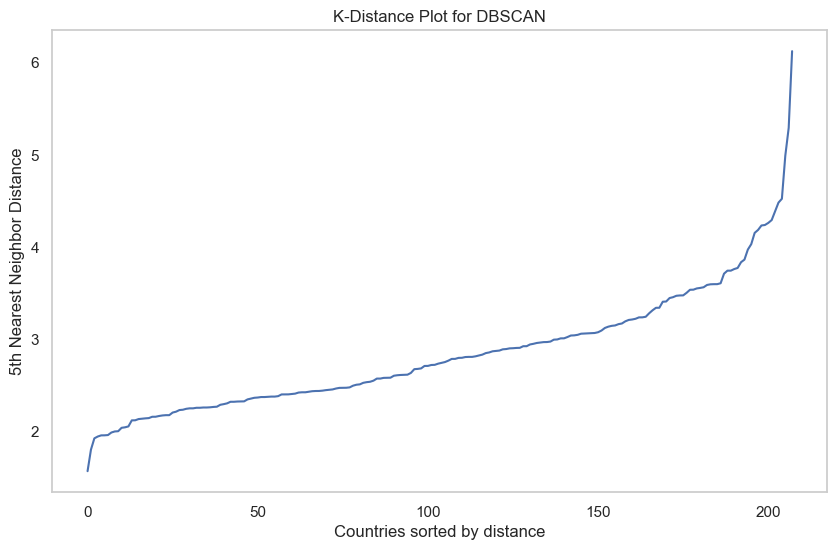

In [124]:
#Plotting k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel('Countries sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Plot for DBSCAN')
plt.grid()
plt.show()

The K-Distance Plot shows that the 5th-nearest-neighbor distance increases gradually up to around 3.5–4.0 and then starts increasing more rapidly. This suggests that an eps value in the range of approximately 3.5 to 4.5 could be suitable for DBSCAN. Therefore, these values will be tested further to identify a suitable clustering configuration.

In [125]:
#DBSCAN tuning
eps_values = [2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0]
min_samples_values = [3, 4, 5, 6, 8, 10]
dbscan_results = []
for min_samples in min_samples_values:
    for eps in eps_values:
        model = DBSCAN(eps=eps,min_samples=min_samples)
        labels = model.fit_predict(df_scaled)
        #Number of clusters excluding noise
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        #Number of noise points
        n_noise = np.sum(labels == -1)
        #Calculating metrics only if at least 2 clusters exist
        if n_clusters >= 2:
            #Removing noise points for evaluation
            non_noise = labels != -1
            evaluation_data = df_scaled[non_noise]
            evaluation_labels = labels[non_noise]
            silhouette = silhouette_score(
                evaluation_data,
                evaluation_labels
            )
            davies_bouldin = davies_bouldin_score(
                evaluation_data,
                evaluation_labels
            )
            calinski_harabasz = calinski_harabasz_score(
                evaluation_data,
                evaluation_labels
            )
        else:
            silhouette = None
            davies_bouldin = None
            calinski_harabasz = None
        #Storing results
        dbscan_results.append({
            'Eps': eps,
            'Min Samples': min_samples,
            'Clusters': n_clusters,
            'Noise Points': n_noise,
            'Silhouette': silhouette,
            'Davies-Bouldin': davies_bouldin,
            'Calinski-Harabasz': calinski_harabasz
        })


In [126]:
#Converting results to DataFrame
dbscan_tuning_results = pd.DataFrame(dbscan_results)
dbscan_tuning_results

,Eps,Min Samples,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2.00,3,9,148,0.257121,1.155789,35.649754
1,2.25,3,7,121,0.346769,1.056034,55.039768
2,2.50,3,5,73,0.242666,1.215653,54.654254
3,2.75,3,1,49,NaN,NaN,NaN
4,3.00,3,2,27,0.140235,1.226054,6.746151
5,3.25,3,1,20,NaN,NaN,NaN
6,3.50,3,1,11,NaN,NaN,NaN
7,3.75,3,1,8,NaN,NaN,NaN
8,4.00,3,1,3,NaN,NaN,NaN
9,2.00,4,6,169,0.271070,1.160801,29.908092


In [127]:
#Creating the tuned DBSCAN model
tuned_dbscan_model = DBSCAN(eps=2.75,min_samples=5)

In [128]:
#Fitting the model and getting cluster labels
tuned_dbscan_labels = tuned_dbscan_model.fit_predict(df_scaled)
#Storing cluster labels
df_clustering['Tuned_DBSCAN_Cluster'] = tuned_dbscan_labels

In [129]:
#Calculating tuned DBSCAN evaluation metrics
non_noise = tuned_dbscan_labels != -1
tuned_dbscan_silhu = silhouette_score(
    df_scaled[non_noise],
    tuned_dbscan_labels[non_noise]
)
tuned_dbscan_db = davies_bouldin_score(
    df_scaled[non_noise],
    tuned_dbscan_labels[non_noise]
)
tuned_dbscan_ch = calinski_harabasz_score(
    df_scaled[non_noise],
    tuned_dbscan_labels[non_noise]
)

In [130]:
print("Tuned DBSCAN Results")
print("--------------------")
print("Eps:", 2.75)
print("Min Samples:", 5)
print("Number of Clusters:", len(set(tuned_dbscan_labels)) - 1)
print("Noise Points:", np.sum(tuned_dbscan_labels == -1))
print("Silhouette Score:", round(tuned_dbscan_silhu, 4))
print("Davies-Bouldin Index:", round(tuned_dbscan_db, 4))
print("Calinski-Harabasz Score:", round(tuned_dbscan_ch, 4))

Tuned DBSCAN Results
--------------------
Eps: 2.75
Min Samples: 5
Number of Clusters: 2
Noise Points: 57
Silhouette Score: 0.2881
Davies-Bouldin Index: 1.1049
Calinski-Harabasz Score: 68.2212


### Visualizations

In [131]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.49964552 0.16427724]


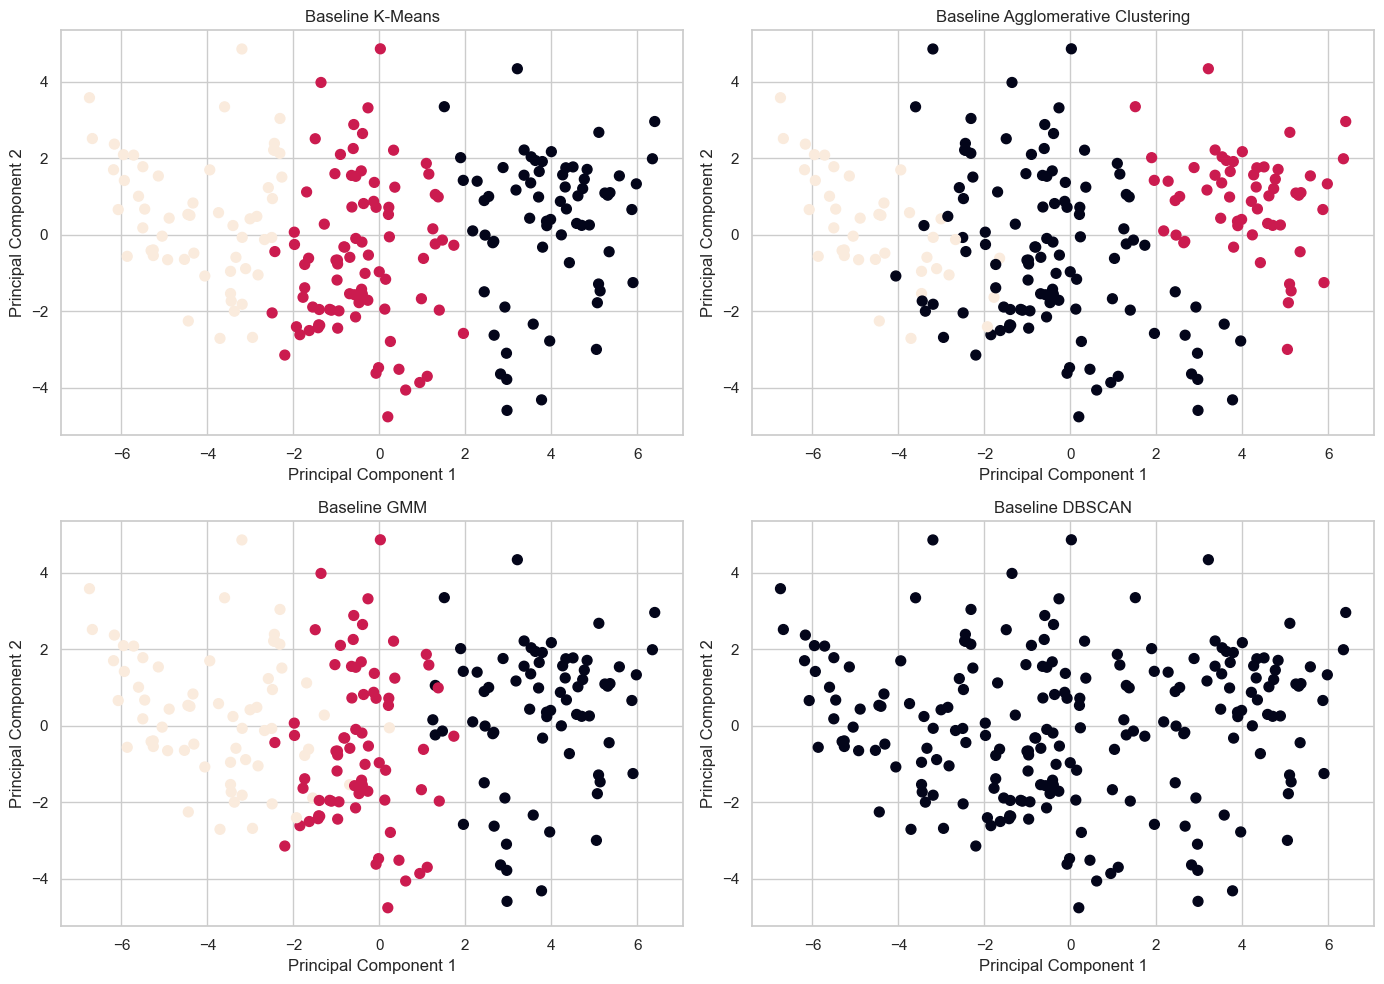

In [132]:
#Plotting baseline clustering models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#K-Means
axes[0, 0].scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=kmeans_labels,
    s=50
)
axes[0, 0].set_title("Baseline K-Means")
axes[0, 0].set_xlabel("Principal Component 1")
axes[0, 0].set_ylabel("Principal Component 2")

#Agglomerative Clustering
axes[0, 1].scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=agglomerative_labels,
    s=50
)
axes[0, 1].set_title("Baseline Agglomerative Clustering")
axes[0, 1].set_xlabel("Principal Component 1")
axes[0, 1].set_ylabel("Principal Component 2")

#GMM
axes[1, 0].scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=gmm_labels,
    s=50
)
axes[1, 0].set_title("Baseline GMM")
axes[1, 0].set_xlabel("Principal Component 1")
axes[1, 0].set_ylabel("Principal Component 2")

#DBSCAN
axes[1, 1].scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=dbscan_labels,
    s=50
)
axes[1, 1].set_title("Baseline DBSCAN")
axes[1, 1].set_xlabel("Principal Component 1")
axes[1, 1].set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

* **K-Means:** The countries are divided into three groups. The clusters are fairly visible, especially along the first principal component.

* **Agglomerative Clustering:** The model also creates three groups. The clusters are somewhat separated, but there is some overlap between the groups in the middle.

* **GMM:** The grouping looks similar to K-Means, with three main groups. Some countries are located between the clusters, showing that the groups are not completely separate.

* **DBSCAN:** The points are not clearly divided into separate groups in this visualization. Most countries appear together, which matches the lower clustering quality seen in the baseline DBSCAN results.

Overall, the K-Means, Agglomerative, and GMM models show some visible grouping of countries, while DBSCAN does not show clear separation in the PCA plot. There is still some overlap between clusters, meaning that the countries do not form completely distinct groups.

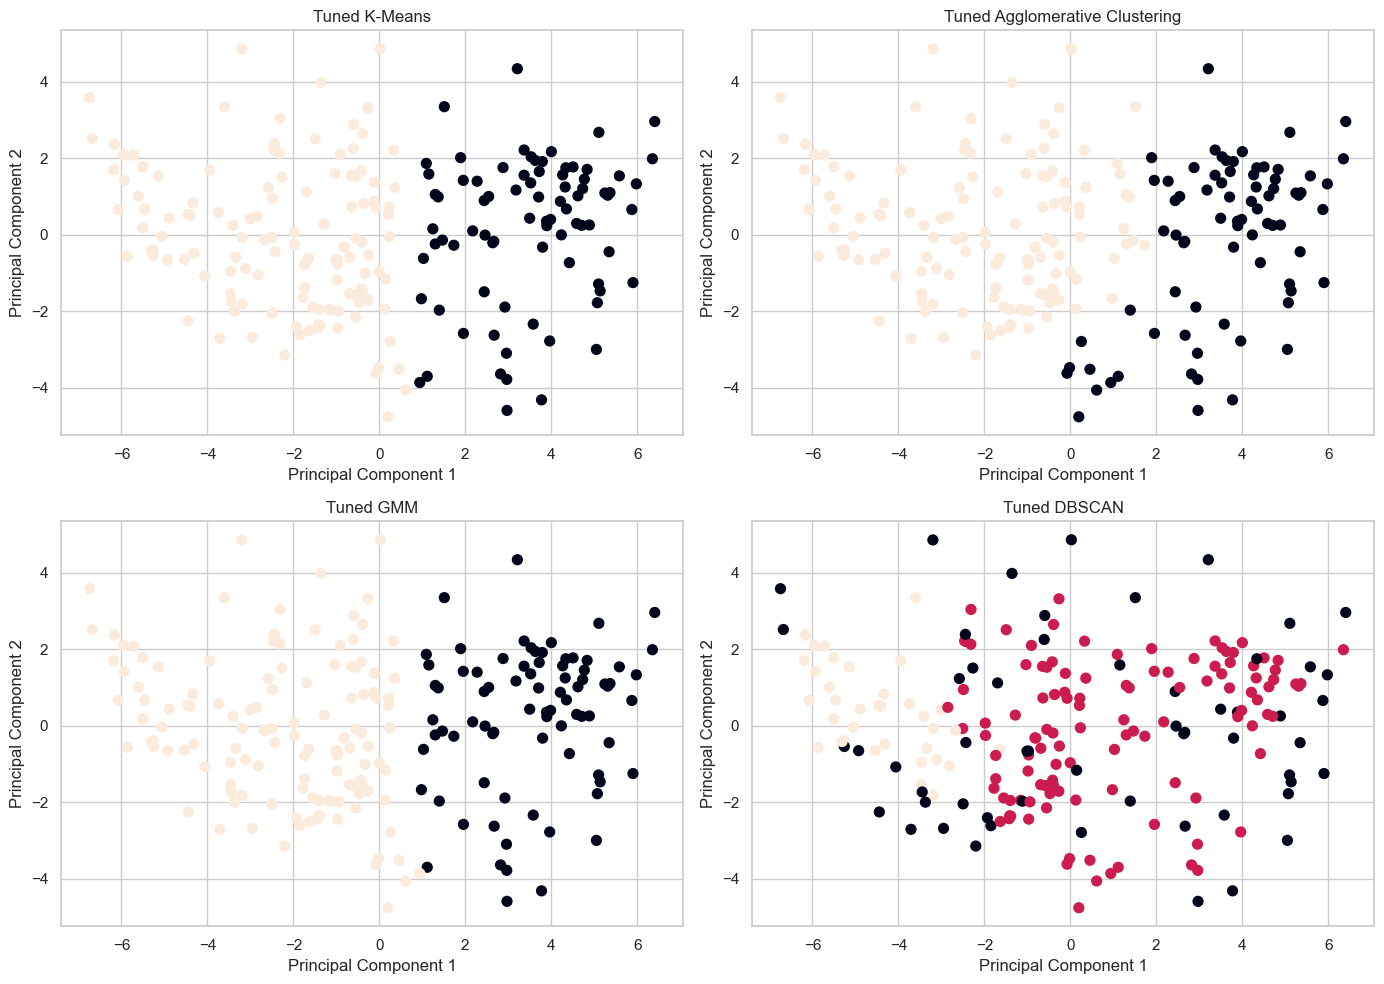

In [133]:
#Plot tuned clustering models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#K-Means
axes[0, 0].scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=tuned_kmeans_labels,
    s=50
)
axes[0, 0].set_title("Tuned K-Means")
axes[0, 0].set_xlabel("Principal Component 1")
axes[0, 0].set_ylabel("Principal Component 2")

#Agglomerative
axes[0, 1].scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=tuned_agglomerative_labels,
    s=50
)
axes[0, 1].set_title("Tuned Agglomerative Clustering")
axes[0, 1].set_xlabel("Principal Component 1")
axes[0, 1].set_ylabel("Principal Component 2")

#GMM
axes[1, 0].scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=tuned_gmm_labels,
    s=50
)
axes[1, 0].set_title("Tuned GMM")
axes[1, 0].set_xlabel("Principal Component 1")
axes[1, 0].set_ylabel("Principal Component 2")

#DBSCAN
axes[1, 1].scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=tuned_dbscan_labels,
    s=50
)
axes[1, 1].set_title("Tuned DBSCAN")
axes[1, 1].set_xlabel("Principal Component 1")
axes[1, 1].set_ylabel("Principal Component 2")


plt.tight_layout()
plt.show()

* **Tuned K-Means:** The model now shows two main groups. The groups are fairly separated along Principal Component 1, although there is still some overlap around the middle.

* **Tuned Agglomerative Clustering:** The result is similar to tuned K-Means, with two groups. Most of the points are separated into a left and right group.

* **Tuned GMM:** GMM also produces two main groups with a clear separation along Principal Component 1. The overall pattern looks quite similar to K-Means and Agglomerative Clustering.

* **Tuned DBSCAN:** DBSCAN shows two clusters along with some points treated as noise. The clusters are more spread out compared with the other models, and the separation is not as clear.

Overall, after tuning K-Means, Agglomerative Clustering, and GMM show clearer separation between the two groups. DBSCAN identifies some countries as noise and produces a more scattered grouping. Overall, the tuned models show a simpler and more clearly separated structure than the baseline models.

### Model Comparison

In [134]:
# Model Performance Comparison
model_comparison = pd.DataFrame({
    'Model': [
        'K-Means',
        'K-Means',
        'Agglomerative',
        'Agglomerative',
        'GMM',
        'GMM',
        'DBSCAN',
        'DBSCAN'
    ],
    'Version': [
        'Baseline',
        'Tuned',
        'Baseline',
        'Tuned',
        'Baseline',
        'Tuned',
        'Baseline',
        'Tuned'
    ],
    'Silhouette': [
        base_kmeans_silhouette,
        tuned_kmeans_silhu,
        base_agglomerative_silhouette,
        tuned_agglomerative_silhu,
        base_gmm_silhouette,
        tuned_gmm_silhu,
        base_dbscan_silhouette,
        tuned_dbscan_silhu
    ],
    'Davies-Bouldin': [
        base_kmeans_davies_bouldin,
        tuned_kmeans_db,
        base_agglomerative_davies_bouldin,
        tuned_agglomerative_db,
        base_gmm_davies_bouldin,
        tuned_gmm_db,
        base_dbscan_davies_bouldin,
        tuned_dbscan_db
    ],
    'Calinski-Harabasz': [
        base_kmeans_calinski_harabasz,
        tuned_kmeans_ch,
        base_agglomerative_calinski_harabasz,
        tuned_agglomerative_ch,
        base_gmm_calinski_harabasz,
        tuned_gmm_ch,
        base_dbscan_calinski_harabasz,
        tuned_dbscan_ch
    ]
})

In [135]:
model_comparison

,Model,Version,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,Baseline,0.224744,1.518186,90.442626
1,K-Means,Tuned,0.303739,1.247658,115.047473
2,Agglomerative,Baseline,0.211911,1.416797,79.971144
3,Agglomerative,Tuned,0.292745,1.299113,104.980685
4,GMM,Baseline,0.196814,1.692954,84.026876
5,GMM,Tuned,0.304410,1.242831,114.971831
6,DBSCAN,Baseline,NaN,NaN,NaN
7,DBSCAN,Tuned,0.288090,1.104923,68.221152


In [136]:
#Cluster Distribution Comparison
print("K-Means:")
print(pd.Series(tuned_kmeans_labels).value_counts().sort_index())

print("\nAgglomerative Clustering:")
print(pd.Series(tuned_agglomerative_labels).value_counts().sort_index())

print("\nGMM:")
print(pd.Series(tuned_gmm_labels).value_counts().sort_index())

print("\nDBSCAN:")
print(pd.Series(tuned_dbscan_labels).value_counts().sort_index())

K-Means:
0     81
1    127
Name: count, dtype: int64

Agglomerative Clustering:
0     76
1    132
Name: count, dtype: int64

GMM:
0     80
1    128
Name: count, dtype: int64

DBSCAN:
-1     57
 0    116
 1     35
Name: count, dtype: int64


In [137]:
#Creating a DataFrame to summarize the cluster distribution for each model
cluster_distribution = pd.DataFrame({
    'Model': [
        'K-Means',
        'Agglomerative',
        'GMM',
        'DBSCAN'
    ],
    'Clusters': [
        len(np.unique(tuned_kmeans_labels)),
        len(np.unique(tuned_agglomerative_labels)),
        len(np.unique(tuned_gmm_labels)),
        len(set(tuned_dbscan_labels)) - (1 if -1 in tuned_dbscan_labels else 0)
    ],
    'Noise Points': [
        0,
        0,
        0,
        np.sum(tuned_dbscan_labels == -1)
    ]
})

In [138]:
cluster_distribution


,Model,Clusters,Noise Points
0,K-Means,2,0
1,Agglomerative,2,0
2,GMM,2,0
3,DBSCAN,2,57


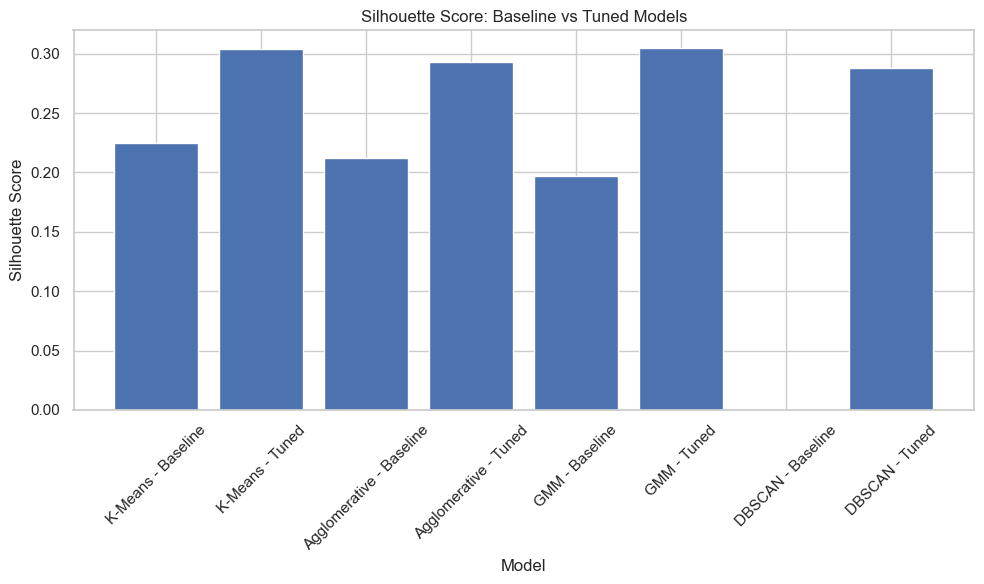

In [139]:
#Silhouette Score Comparison
plt.figure(figsize=(10, 6))
plt.bar(
    model_comparison['Model'] + ' - ' + model_comparison['Version'],
    model_comparison['Silhouette']
)
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score: Baseline vs Tuned Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* The tuned models generally have higher Silhouette Scores than their baseline versions.
* K-Means improved from about 0.225 to 0.304 after tuning.
* Agglomerative Clustering improved from about 0.212 to 0.293.
* GMM showed the biggest improvement, from about 0.197 to 0.304.
* The tuned GMM and K-Means have very similar Silhouette Scores.
* DBSCAN's baseline score is missing because it did not form valid clusters, while the tuned DBSCAN achieved about 0.288.
* Overall, tuning improved the clustering quality for all the models that could be evaluated.

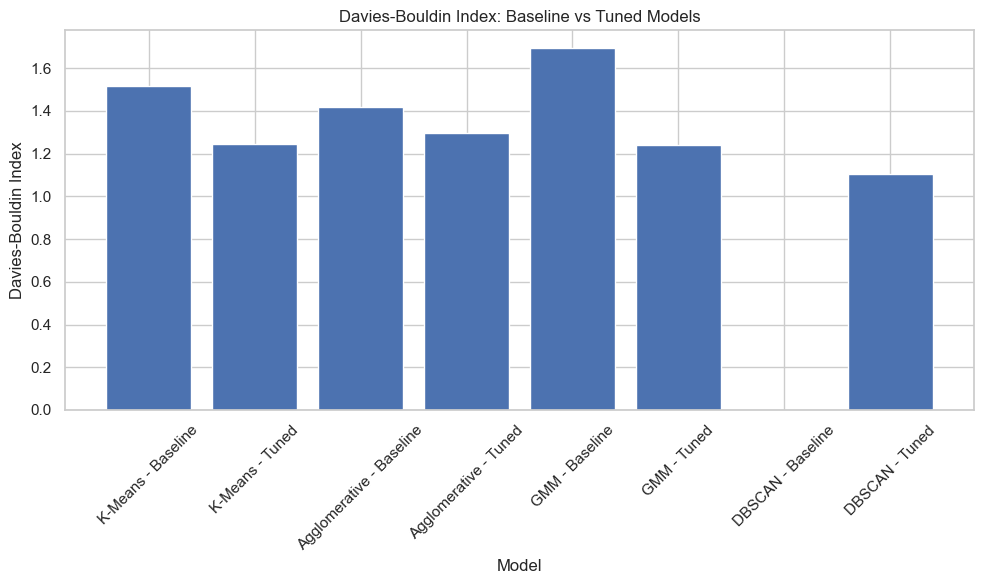

In [140]:
#Davies-Bouldin Index Comparison
plt.figure(figsize=(10, 6))
plt.bar(
    model_comparison['Model'] + ' - ' + model_comparison['Version'],
    model_comparison['Davies-Bouldin']
)
plt.xlabel("Model")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index: Baseline vs Tuned Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* The Davies-Bouldin Index decreased after tuning for all the models that could be evaluated.
* K-Means decreased from about 1.52 to 1.25.
* Agglomerative Clustering decreased from about 1.42 to 1.30.
* GMM showed a clear decrease from about 1.69 to 1.24.
* Tuned DBSCAN has a Davies-Bouldin Index of about 1.10.
* Since a lower Davies-Bouldin Index is better, these results show an improvement after tuning.
* DBSCAN's baseline value is missing because the baseline model did not form at least two clusters.

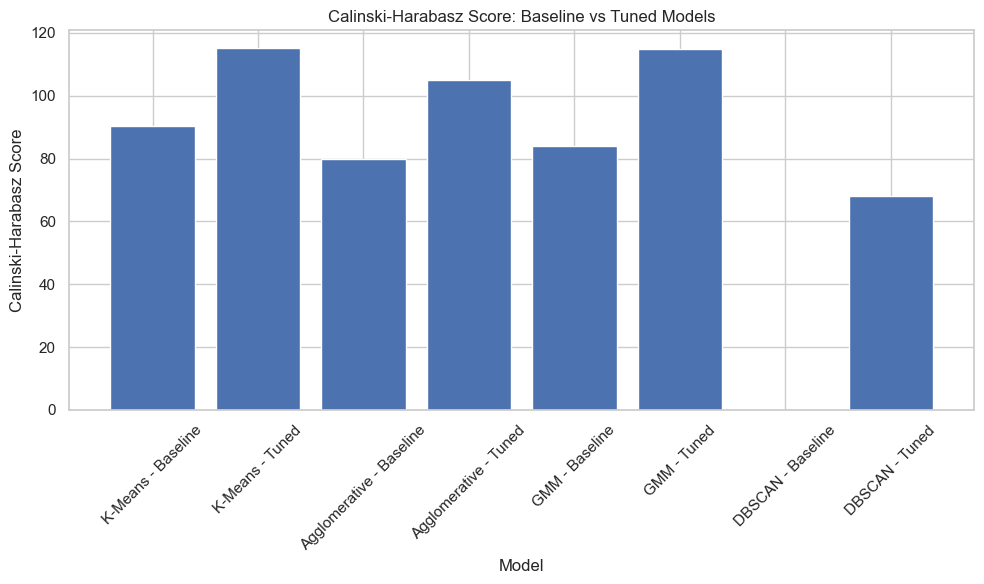

In [141]:
#Calinski-Harabasz Score Comparison
plt.figure(figsize=(10, 6))
plt.bar(
    model_comparison['Model'] + ' - ' + model_comparison['Version'],
    model_comparison['Calinski-Harabasz']
)
plt.xlabel("Model")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Score: Baseline vs Tuned Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* The Calinski-Harabasz Score increased after tuning for all the models that could be evaluated.
* K-Means increased from about 90.44 to 115.05.
* Agglomerative Clustering increased from about 79.97 to 104.98.
* GMM increased from about 84.03 to 114.97.
* Tuned K-Means and GMM have very similar scores.
* Tuned DBSCAN has a score of about 68.22.
* Since a higher Calinski-Harabasz Score is better, the results show that tuning improved the clustering separation for the evaluated models.
* DBSCAN's baseline value is missing because it did not form at least two clusters.

In [142]:
#Final comparison of selected clustering models
final_model_comparison = pd.DataFrame({
    'Model': [
        'K-Means',
        'Agglomerative',
        'GMM',
        'DBSCAN'
    ],
    'Parameters': [
        'K=2',
        'Complete linkage, K=2',
        'Spherical, K=2',
        'Eps=2.75, Min Samples=5'
    ],
    'Clusters': [
        2,
        2,
        2,
        2
    ],
    'Noise': [
        0,
        0,
        0,
        57
    ],
    'Silhouette': [
        tuned_kmeans_silhu,
        tuned_agglomerative_silhu,
        tuned_gmm_silhu,
        tuned_dbscan_silhu
    ],
    'Davies-Bouldin': [
        tuned_kmeans_db,
        tuned_agglomerative_db,
        tuned_gmm_db,
        tuned_dbscan_db
    ],
    'Calinski-Harabasz': [
        tuned_kmeans_ch,
        tuned_agglomerative_ch,
        tuned_gmm_ch,
        tuned_dbscan_ch
    ]
})

final_model_comparison

,Model,Parameters,Clusters,Noise,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,K=2,2,0,0.303739,1.247658,115.047473
1,Agglomerative,"Complete linkage, K=2",2,0,0.292745,1.299113,104.980685
2,GMM,"Spherical, K=2",2,0,0.304410,1.242831,114.971831
3,DBSCAN,"Eps=2.75, Min Samples=5",2,57,0.288090,1.104923,68.221152


In [143]:
#Cluster size comparison
cluster_distribution = pd.DataFrame({
    'Model': [
        'K-Means',
        'Agglomerative',
        'GMM',
        'DBSCAN'
    ],
    'Cluster 0': [
        pd.Series(tuned_kmeans_labels).value_counts().get(0, 0),
        pd.Series(tuned_agglomerative_labels).value_counts().get(0, 0),
        pd.Series(tuned_gmm_labels).value_counts().get(0, 0),
        pd.Series(tuned_dbscan_labels).value_counts().get(0, 0)
    ],
    'Cluster 1': [
        pd.Series(tuned_kmeans_labels).value_counts().get(1, 0),
        pd.Series(tuned_agglomerative_labels).value_counts().get(1, 0),
        pd.Series(tuned_gmm_labels).value_counts().get(1, 0),
        pd.Series(tuned_dbscan_labels).value_counts().get(1, 0)
    ],
    'Noise': [
        0,
        0,
        0,
        pd.Series(tuned_dbscan_labels).value_counts().get(-1, 0)
    ]
})

cluster_distribution

,Model,Cluster 0,Cluster 1,Noise
0,K-Means,81,127,0
1,Agglomerative,76,132,0
2,GMM,80,128,0
3,DBSCAN,116,35,57


* K-Means produced 81 countries in Cluster 0 and 127 countries in Cluster 1.
* Agglomerative Clustering produced 76 countries in Cluster 0 and 132 countries in Cluster 1.
* GMM produced 80 countries in Cluster 0 and 128 countries in Cluster 1.
* DBSCAN produced 116 countries in Cluster 0 and 35 countries in Cluster 1, with 57 countries classified as noise.
* K-Means, Agglomerative Clustering, and GMM have fairly similar cluster distributions.
* DBSCAN has a more uneven distribution and a relatively large number of noise points.
* These cluster-size differences will be considered along with the clustering evaluation metrics when selecting the final model.

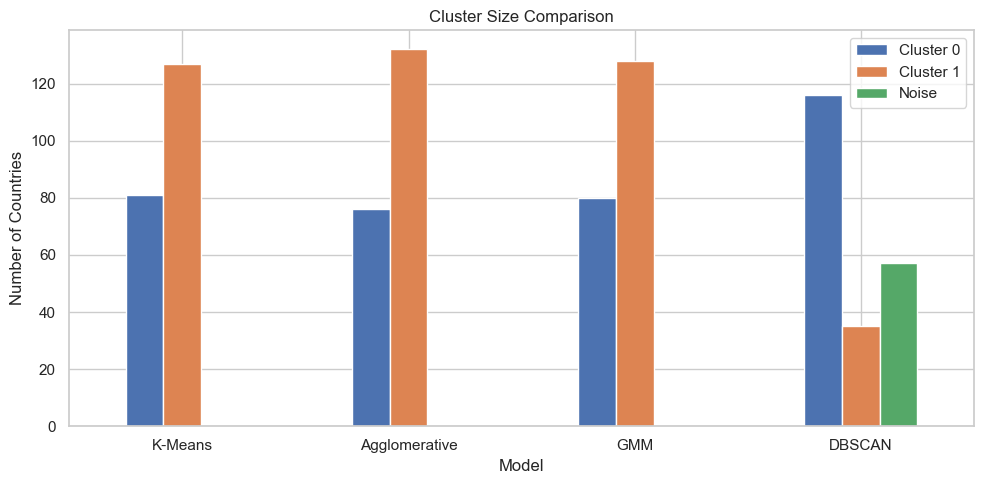

In [144]:
#Plotting the cluster size comparison for each model
cluster_distribution.set_index('Model')[['Cluster 0', 'Cluster 1', 'Noise']].plot(
    kind='bar',
    figsize=(10, 5)
)
plt.title("Cluster Size Comparison")
plt.xlabel("Model")
plt.ylabel("Number of Countries")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* K-Means, Agglomerative, and GMM have fairly similar cluster sizes, with one larger cluster and one smaller cluster.
* K-Means has 81 countries in Cluster 0 and 127 in Cluster 1.
* Agglomerative has 76 countries in Cluster 0 and 132 in Cluster 1.
* GMM has 80 countries in Cluster 0 and 128 in Cluster 1.
* DBSCAN has a different distribution, with 116 countries in Cluster 0, 35 in Cluster 1, and 57 noise points.
* DBSCAN leaves a relatively large number of countries as noise compared with the other models.
* Overall, K-Means, Agglomerative, and GMM produce more consistent cluster distributions, while DBSCAN produces a more uneven distribution.

### Final Model Selection

K-Means and GMM produced similar results across the clustering metrics, with balanced cluster sizes.

Agglomerative Clustering also produced reasonably balanced clusters, but its evaluation scores were slightly lower than K-Means and GMM.

DBSCAN had the lowest Davies-Bouldin Index, but it classified 57 countries as noise and produced a less balanced cluster distribution.

Based on the combination of evaluation metrics, cluster sizes, and the number of noise points, K-Means and GMM provide similar and consistent clustering results for the dataset.

### Interpretation

In [145]:
#Adding the tuned K-Means cluster labels to the country-level dataset
df_clustering["Cluster"] = tuned_kmeans_labels

#Calculating the median value of each feature for each cluster
cluster_profile = df_clustering.groupby("Cluster").median(numeric_only=True)

In [146]:
cluster_profile

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,KMeans_Cluster,Agglomerative_Cluster,GMM_Cluster,DBSCAN_Cluster,Tuned_KMeans_Cluster,Tuned_Agglomerative_Cluster,Tuned_GMM_Cluster,Tuned_DBSCAN_Cluster
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.035,3.722072,7.499977,3.610918,8.824898,22.44580,0.056,3.871201,5.442418,0.057,0.0,-1.937942,61.0,58.0,0.15,0.415,0.551,0.033,15.754903,0.356,18.459901,18.515991,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0
1,0.014,3.712352,10.385636,3.218876,9.506511,24.38542,0.061,5.916202,5.442418,0.012,0.3,-2.207275,78.0,72.0,0.80,0.238,0.668,0.077,15.476833,0.686,21.346527,20.678268,1.0,0.0,2.0,-1.0,1.0,1.0,1.0,0.0


* The tuned K-Means model divided the countries into two clusters.
* Cluster 0 has a higher birth rate and infant mortality rate than Cluster 1.
* Cluster 1 has higher life expectancy, internet usage, mobile phone usage, and urban population.
* Cluster 0 has a higher share of population aged 0–14, while Cluster 1 has higher shares of the 15–64 and 65+ age groups.
* Cluster 1 also has higher health expenditure per capita.
* Overall, the two clusters show differences in demographic, health, technology, and urbanization indicators.

In [147]:
#Comparing the cluster profiles
cluster_comparison = cluster_profile.T
cluster_comparison["Difference"] = (cluster_comparison[1] - cluster_comparison[0])

In [148]:
cluster_comparison

Cluster,0,1,Difference
Birth Rate,0.035000,0.014000,-0.021000
Business Tax Rate,3.722072,3.712352,-0.009721
CO2 Emissions,7.499977,10.385636,2.885659
Days to Start Business,3.610918,3.218876,-0.392042
Energy Usage,8.824898,9.506511,0.681613
GDP,22.445800,24.385420,1.939620
Health Exp % GDP,0.056000,0.061000,0.005000
Health Exp/Capita,3.871201,5.916202,2.045001
Hours to do Tax,5.442418,5.442418,0.000000
Infant Mortality Rate,0.057000,0.012000,-0.045000


* Cluster 1 has a lower birth rate and infant mortality rate compared to Cluster 0.
* Cluster 1 has higher GDP, health expenditure per capita, and CO2 emissions.
* Cluster 1 has much higher female and male life expectancy than Cluster 0.
* Internet usage and mobile phone usage are also higher in Cluster 1.
* Cluster 0 has a higher share of population aged 0–14, while Cluster 1 has higher shares of the 15–64 and 65+ age groups.
* Cluster 1 has a higher urban population and higher inbound and outbound tourism values.
* Overall, Cluster 1 shows higher values in several health, economic, technology, and urbanization indicators, while Cluster 0 has higher birth and infant mortality rates.

In [149]:
#Displaying countries belonging to each cluster
country_cluster_list = pd.DataFrame({
    "Country": df_country.index,
    "Cluster": tuned_kmeans_labels
})

country_cluster_list.sort_values(by=["Cluster", "Country"])

,Country,Cluster
0,Afghanistan,0
5,Angola,0
15,Bangladesh,0
19,Belize,0
20,Benin,0
...,...,...
198,United States,1
199,Uruguay,1
202,"Venezuela, RB",1
203,Vietnam,1


In [150]:
for cluster in sorted(country_cluster_list["Cluster"].unique()):
    print(f"\nCluster {cluster}:")
    print(
        country_cluster_list[
            country_cluster_list["Cluster"] == cluster
        ]["Country"].tolist()
    )


Cluster 0:
['Afghanistan', 'Angola', 'Bangladesh', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Botswana', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Djibouti', 'Equatorial Guinea', 'Eritrea', 'Ethiopia', 'Fiji', 'Gabon', 'Gambia, The', 'Ghana', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Iraq', 'Kenya', 'Kiribati', 'Kyrgyz Republic', 'Lao PDR', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Marshall Islands', 'Mauritania', 'Micronesia, Fed. Sts.', 'Mongolia', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal', 'Nicaragua', 'Niger', 'Nigeria', 'Pakistan', 'Papua New Guinea', 'Paraguay', 'Rwanda', 'Samoa', 'Sao Tome and Principe', 'Senegal', 'Sierra Leone', 'Solomon Islands', 'Somalia', 'South Sudan', 'St. Vincent and the Grenadines', 'Sudan', 'Suriname', 'Swaziland', 'Tajikistan', 'Tanzania', 'Timor-Leste', 'Togo', 'Tonga', 'Turkmenistan', 'Ug

* Cluster 0 contains countries such as Afghanistan, Angola, Bangladesh, Belize, and Benin.
* Cluster 1 contains countries such as the United States, Uruguay, Venezuela, Vietnam, and the Virgin Islands.
* The clustering divides the 208 countries into two groups based on their development-related indicators.
* The countries in Cluster 0 generally show lower values for several health, technology, and urbanization indicators.
* The countries in Cluster 1 generally show higher values for these indicators.

In [153]:
import os, json
import numpy as np

os.makedirs("streamlit_app/data", exist_ok=True)

features = list(df_scaled.columns)                      # the 22 model features
model_ready = df_clustering[features].copy()            # country-level, log-transformed
model_ready.to_csv("streamlit_app/data/country_features.csv")

meta = {"features": features, "log_cols": [str(c) for c in transform_cols]}
with open("streamlit_app/data/meta.json", "w") as f:
    json.dump(meta, f, indent=2)

final_model_comparison.to_csv("streamlit_app/data/model_comparison.csv", index=False)
print("Saved:", os.listdir("streamlit_app/data"))

Saved: ['country_features.csv', 'meta.json', 'model_comparison.csv']
